## "So, we have the Titanic dataset. Let's find out if a third-party person would survive if they were on board."

## Rumor has it that supposedly the Titanic was unsinkable, and no one expected such a terrible tragedy to occur. 


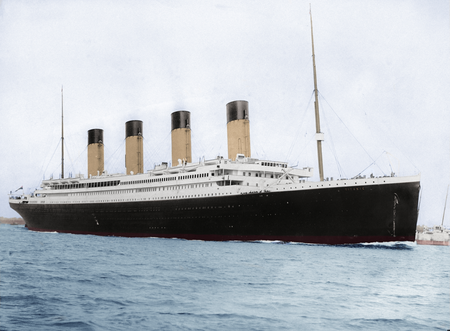

In [123]:
from IPython.display import Image

immage_sor='../titanic/Titanic_in_color2.png'

display(Image(filename = immage_sor))


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pickle

pd.set_option('display.max_columns', None)

from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser, DecisionTreeDiscretiser, EqualWidthDiscretiser
from feature_engine.imputation import MeanMedianImputer, RandomSampleImputer, ArbitraryNumberImputer, CategoricalImputer

from xgboost import XGBClassifier

In [125]:
#All the functions

def classify_variables(data):
    discrete = [var for var in data.columns if data[var].dtypes != 'O' and var != 'survived' and data[var].nunique() < 10]
    continous = [var for var in data.columns if data[var].dtypes != 'O' and var != 'survived' and var not in discrete]
    mixed = ['cabin','ticket']
    categorical = [var for var in data.columns if data[var].dtypes == 'O' and var != 'survived' and var not in mixed]

    print('{} discrete variables'.format(len(discrete)))
    print(discrete)
    print()
    print('{} continuos variables'.format(len(continous)))
    print(continous)
    print()
    print('{} mixed variables'.format(len(mixed)))
    print(mixed)
    print()
    print('{} categorical variables'.format(len(categorical)))
    print(categorical)

    
def check_groped_target_by_feature(data, target, variable):
    grouped_data=data[target].groupby(data[variable]).sum()
    plt.figure(figsize=(6,4)) 
    grouped_data.plot(kind = 'bar')
    #grouped_data.plot(kind = 'bar',color = ['skyblue','orange'])
    plt.title('Count of '+target)
    plt.xlabel(variable)
    plt.ylabel('Count')
    plt.xticks(rotation = 0)
    plt.tight_layout()
    plt.show()

def check_missing_values(data):
    missing_values = data.isnull().mean()
    missing_values = missing_values.sort_values(ascending=False)
    plt.figure(figsize=(8,6))
    plt.bar(missing_values.index, missing_values.values)
    plt.xlabel('Features')
    plt.ylabel('Number of missing values')
    plt.title('Numbers of missing values')
    plt.xticks(rotation = 30)
    plt.show()

def diagnostic_plots(data,variable):
    plt.figure(figsize = (15,6))
    
    # histplot
    plt.subplot(1,2,1)
    sns.histplot(data[variable], bins = 30)
    plt.title('Histogram')
    
    # boxplot
    plt.subplot(1,2,2)
    stats.probplot(data[variable], dist = 'norm',plot = plt)
    plt.ylabel('Quantiles')   
    
    plt.show()
    
def categorical_plot(data, column):
    plt.figure(figsize=(15, 6))
    value_counts = data[column].value_counts()
    value_counts.plot(kind = 'bar', color = 'green')
    plt.title('Categories')
    plt.xlabel('Categories')
    plt.xlabel('Frequency')
    plt.xticks(rotation = 0)
    procent = 0.05 * value_counts.sum()
    plt.axhline(y = procent, color = 'red', linestyle = '--', label = '5% line')
    plt.legend()
    plt.show()
    
def countplot(data, column):
    plt.figure(figsize = (1,6))
    data[column].plot(kind = 'bar')
    plt.title('Categories')
    plt.xlabel('Count')
    ply.ylabel('Survived')
    plt.show()
    
def impute_na(data,variable):
    
    df = data.copy()
    
    df[variable + '_random'] = df[variable]
    random_sample = data[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable + '_random'] = random_sample
    
    return df[variable + '_random']

def categorical_to_ordered(data,variable):
    df = data.copy()
    for col in ['sex', 'cabin', 'embarked']:
        
        ordered_labels = df.groupby([col])['survived'].mean().sort_values().index
        ordinal_label = {
            k: i
            for i, k in enumerate(ordered_labels, 0)   
        }
        
        df_temp[col] = df[col].map(ordinal_label)
 
    
    return df_train_temp

def subplot(X_original,X_imputed, variable, method_of_imputation):
    fig = plt.figure()
    ax = fig.add_subplot(111)

    X_original[variable].plot(kind = 'kde', ax = ax, color = 'blue')
    X_imputed[variable].plot(kind = 'kde', ax = ax, color = 'green')


    lines, labels = ax.get_legend_handles_labels()
    labels = ['original', method_of_imputation]
    ax.legend(lines, labels, loc = 'best')
    plt.title('Variable '+ variable+ ' after imputation')
    plt.show()
    
def print_variance_of_method(X_original,X_imputed, variable):
    print('Variance of '+ variable + ' before imputation: '+ str(X_original[variable].var())+ 
          ' and after :'+ str(X_imputed[variable].var()))
    
def print_variance_of_methods(variable):
    print("original :", X_train[variable].var())
    print("random_sample :" ,X_train_random_sample[variable].var())
    print("mean_median :", X_train_mean_median[variable].var())
    print("arbitrary :", X_train_arbitrary[variable].var())
    print("knn :", X_train_KNN[variable].var())
    
def show_grouped_plot(X_train, y_train, groupby_variable,mean_variable):
    pd.concat([X_train, y_train], axis = 1).groupby(groupby_variable)[mean_variable].mean().plot()
    plt.ylabel('mean of '+mean_variable)
    plt.show()
    
def show_impact_subplot(data, impact_var,impacted_var):
    fig, ax=plt.subplots(figsize=(8,6))
    sns.countplot(x=impacted_var, data=data,hue=impact_var ,order=data[impacted_var].value_counts().index) # 
    #ax.set_ylim(0,1000)
    plt.title("Impact of "+ impact_var+' on ' + impacted_var)
    plt.show()
    
def check_balance_of_discretized(train_t, test_t, var):
    
    t1 = train_t.groupby([var])[var].count() / len(train_t)
    t2 = test_t.groupby([var])[var].count() / len(test_t)

    tmp = pd.concat([t1, t2], axis = 1)
    tmp.columns = ['train', 'test']
    tmp.plot.bar()
    plt.xticks(rotation = 0)
    plt.ylabel('Number of observations per bin')
    plt.show()

## Import Dataset

In [126]:
pd.set_option('display.max_columns', None)
data = pd.read_csv('../titanic/titanic.csv')
data.head(50)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


### Description of features meaning
* PassengerId: Unique identification number of passenger
* Survived: Survival inex (1 - survived, 0 - dead)
* Pclass: passenger class (1, 2 or 3).
* Name: Name of passenger
* Sex: Sex of passenger
* Age: Age of passenger
* SibSp: Amount of siblings or spouse on the  on board
* Parch: Anount of parents or children on the  on board
* Ticket: ticket number
* Fare: ticket fare
* Cabin: number of cabin on the board
* Embarked: Embarkation port (C - Cherbourg, Q - Queenstown, S - Southampton)
* Body: body identification number
* home.dest : Home/Destination
* Boat: LifeBoat

In [127]:
data.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [128]:
data.shape, data.dtypes

((1309, 14),
 pclass         int64
 survived       int64
 name          object
 sex           object
 age          float64
 sibsp          int64
 parch          int64
 ticket        object
 fare         float64
 cabin         object
 embarked      object
 boat          object
 body         float64
 home.dest     object
 dtype: object)

## Classification of variables

In [129]:
classify_variables(data)

3 discrete variables
['pclass', 'sibsp', 'parch']

3 continuos variables
['age', 'fare', 'body']

2 mixed variables
['cabin', 'ticket']

5 categorical variables
['name', 'sex', 'embarked', 'boat', 'home.dest']


In [130]:
for var in data.columns:
    print (var, data[var].unique()[0:10], '\n') #unique values

pclass [1 2 3] 

survived [1 0] 

name ['Allen, Miss. Elisabeth Walton' 'Allison, Master. Hudson Trevor'
 'Allison, Miss. Helen Loraine' 'Allison, Mr. Hudson Joshua Creighton'
 'Allison, Mrs. Hudson J C (Bessie Waldo Daniels)' 'Anderson, Mr. Harry'
 'Andrews, Miss. Kornelia Theodosia' 'Andrews, Mr. Thomas Jr'
 'Appleton, Mrs. Edward Dale (Charlotte Lamson)' 'Artagaveytia, Mr. Ramon'] 

sex ['female' 'male'] 

age [29.      0.9167  2.     30.     25.     48.     63.     39.     53.
 71.    ] 

sibsp [0 1 2 3 4 5 8] 

parch [0 2 1 4 3 5 6 9] 

ticket ['24160' '113781' '19952' '13502' '112050' '11769' 'PC 17609' 'PC 17757'
 'PC 17477' '19877'] 

fare [211.3375 151.55    26.55    77.9583   0.      51.4792  49.5042 227.525
  69.3     78.85  ] 

cabin ['B5' 'C22' 'E12' 'D7' 'A36' 'C101' nan 'C62' 'B35' 'A23'] 

embarked ['S' 'C' nan 'Q'] 

boat ['2' '11' nan '3' '10' 'D' '4' '9' '6' 'B'] 

body [ nan 135.  22. 124. 148. 208. 172. 269.  62. 133.] 

home.dest ['St Louis, MO' 'Montreal, PQ / Ch

## Lets see how many features have missing values

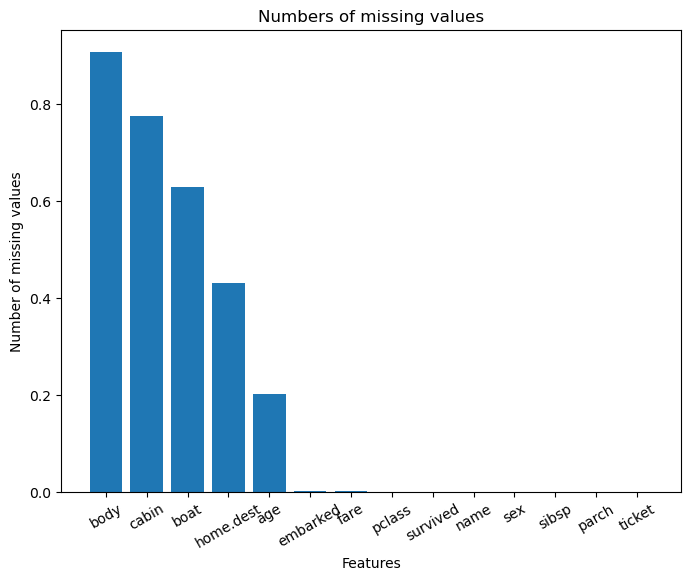

In [131]:
check_missing_values(data)

In [132]:
data.isnull().mean()*100 # missing value in percentage 

pclass        0.000000
survived      0.000000
name          0.000000
sex           0.000000
age          20.091673
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare          0.076394
cabin        77.463713
embarked      0.152788
boat         62.872422
body         90.756303
home.dest    43.086325
dtype: float64

In [134]:
data.dtypes # types of values

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

In [135]:
# The 'name' variable cannot be used in further manipulations, due to the fact that each name is unique, 
# thereby exacerbating the discovery of patterns and dependencies.

# the 'body' variable has more than 90 percent empty values and it only means the 
#registration number of the found body

# the 'home.dest' variable has a large number of unique values 
# thereby exacerbating the discovery of patterns and dependencies. 

data.drop(['name', 'body', 'home.dest'], axis = 1, inplace = True)

#### So we have discrete, continuos also mixed features, sorting by groups

<Axes: xlabel='survived', ylabel='count'>

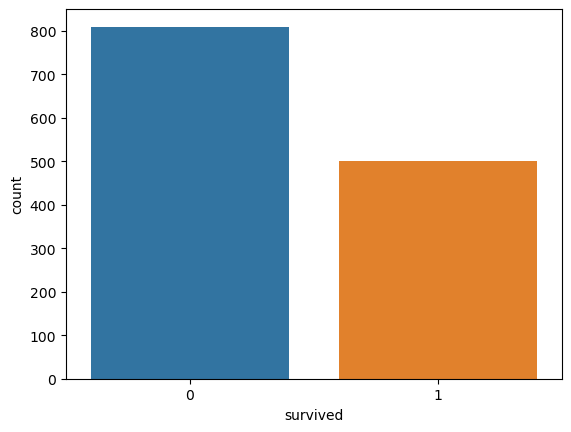

In [136]:
sns.countplot(x = data['survived'], label = 'count')

##### Evacuation Rules

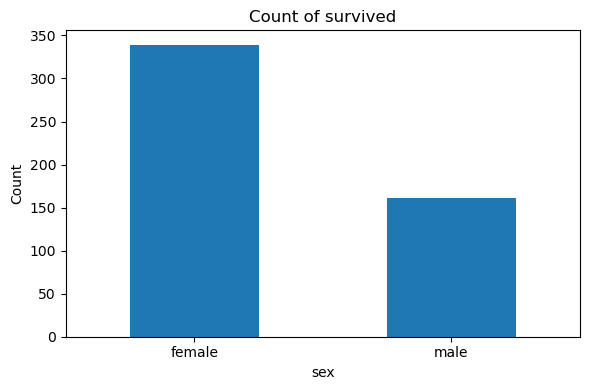

In [137]:
check_groped_target_by_feature(data, 'survived', 'sex')

###### now we can see that majority of survived passenger were  women 'female'

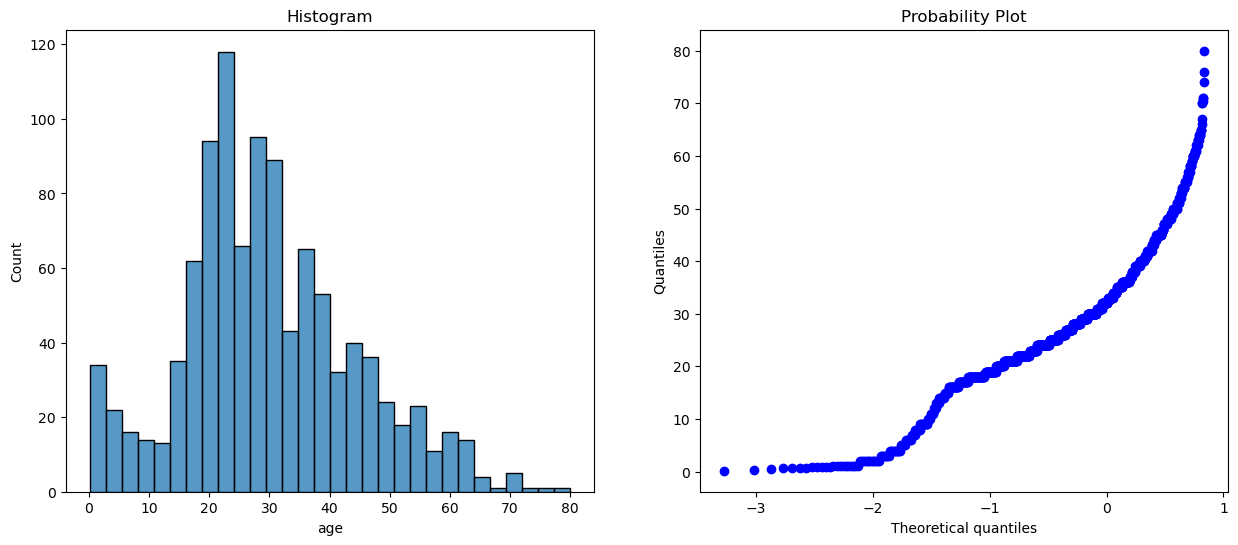

In [138]:
#lets check the age groups of survived passengers
diagnostic_plots(data,'age')

In [139]:
#there is a lot of values in this feature, lets try to group it by segments
data['age_random_imputed']= impute_na(data,'age')
data['age_random_imputed'].isnull().mean()

buckets = [0,20,30,40,60,90]
labels = ['0-20','20-30','30-40','40-60','>60']
data['age_groups'] = pd.cut(
    data['age_random_imputed'],
    bins = buckets,
    labels = labels,
    include_lowest= True
)

data['age_groups'] = pd.cut(
    data['age_random_imputed'],
    bins=buckets,
    include_lowest= True
)

data[['survived','age_random_imputed','age_groups','sex']].head(10)

,survived,age_random_imputed,age_groups,sex
0,1,29.0000,"(20.0, 30.0]",female
1,1,0.9167,"(-0.001, 20.0]",male
2,0,2.0000,"(-0.001, 20.0]",female
3,0,30.0000,"(20.0, 30.0]",male
4,0,25.0000,"(20.0, 30.0]",female
5,1,48.0000,"(40.0, 60.0]",male
6,1,63.0000,"(60.0, 90.0]",female
7,0,39.0000,"(30.0, 40.0]",male
8,1,53.0000,"(40.0, 60.0]",female
9,0,71.0000,"(60.0, 90.0]",male


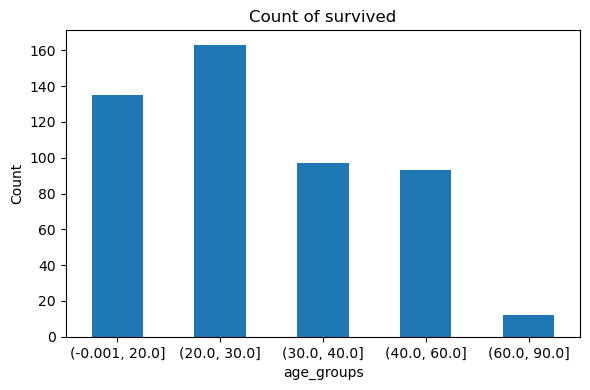

In [140]:
check_groped_target_by_feature(data, 'survived', 'age_groups')

In [141]:
#lets drop features that were made only for visualisation the theory 
data.drop(['age_random_imputed','age_groups'], axis= 1, inplace= True)

In [142]:
#the most survived age is from 20-30 years. Second is from 0 to 20 years which is kind of proving theory that 
#women and kids were evacuated first

###### pclass

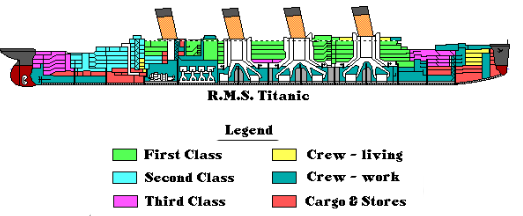

In [143]:
immage_sor='../titanic/titanic_class.png'

display(Image(filename = immage_sor))

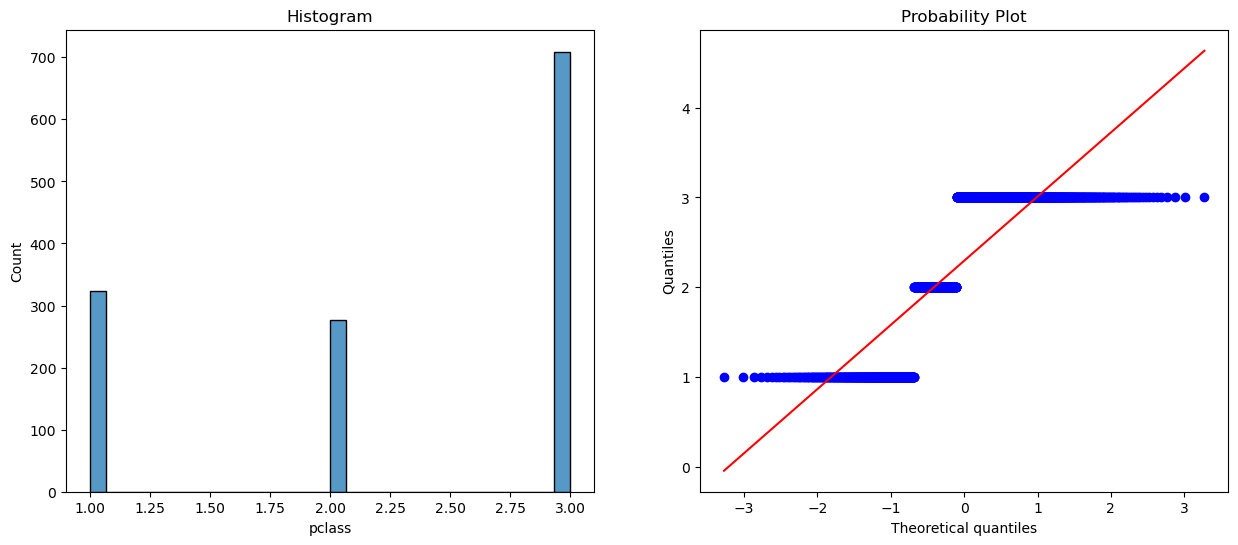

In [144]:
diagnostic_plots(data,'pclass')

In [145]:
# according to the hist and plot that there are many more 3rd class passengers that 1st and 2nd

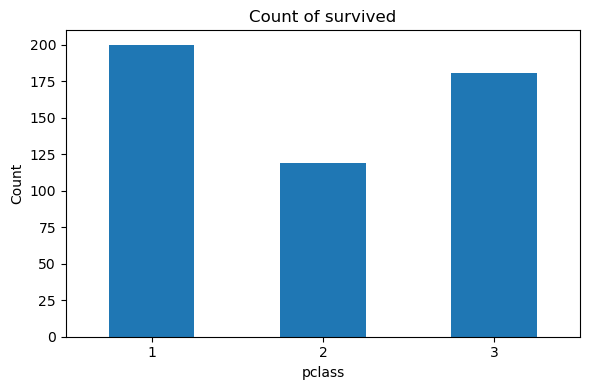

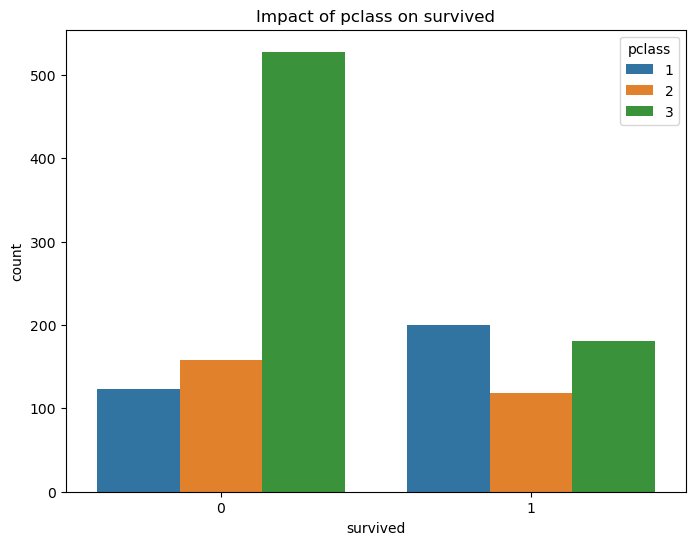

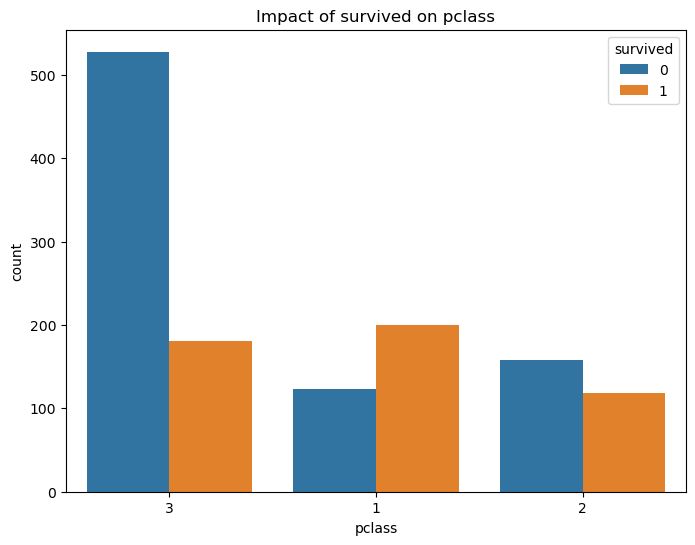

In [146]:
check_groped_target_by_feature(data,'survived', 'pclass')
show_impact_subplot(data,'pclass', 'survived')
show_impact_subplot(data,'survived','pclass')

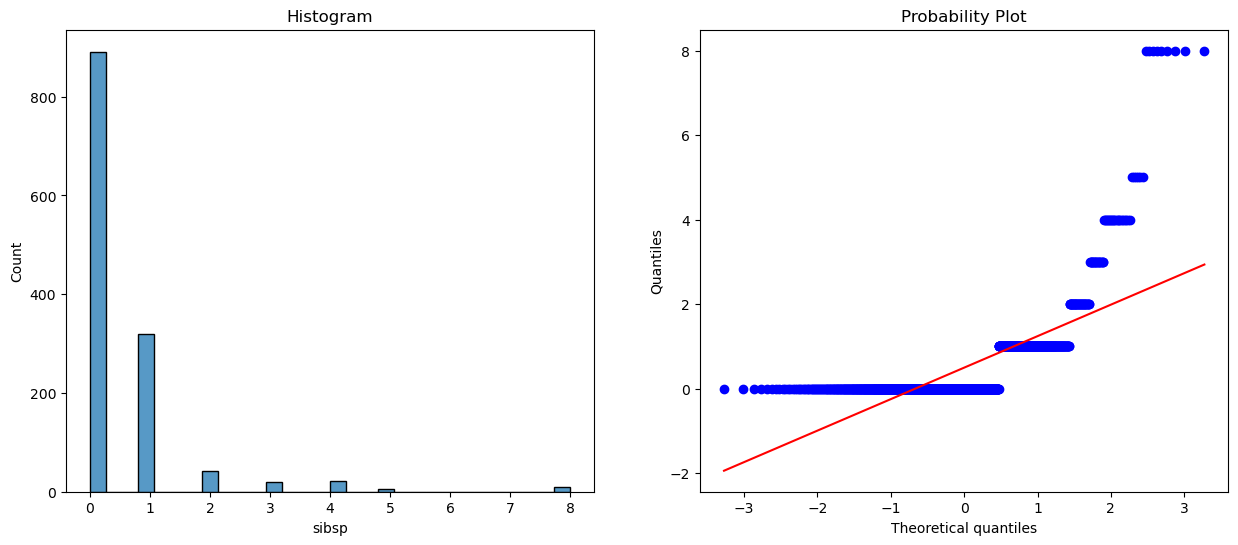

In [147]:
diagnostic_plots(data,'sibsp')

###### sibsp and parch

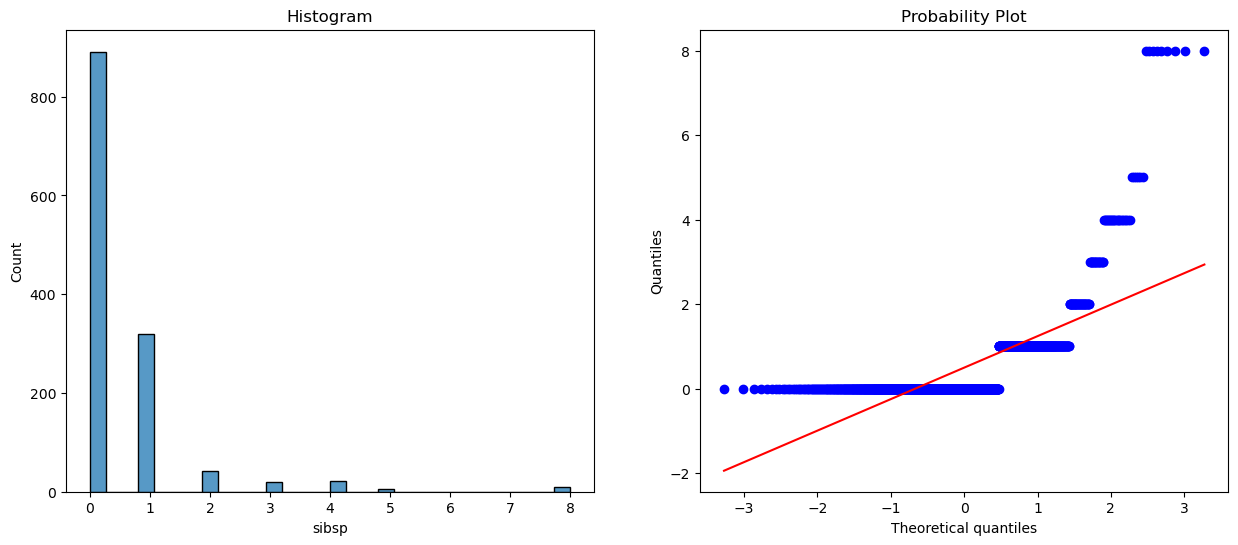

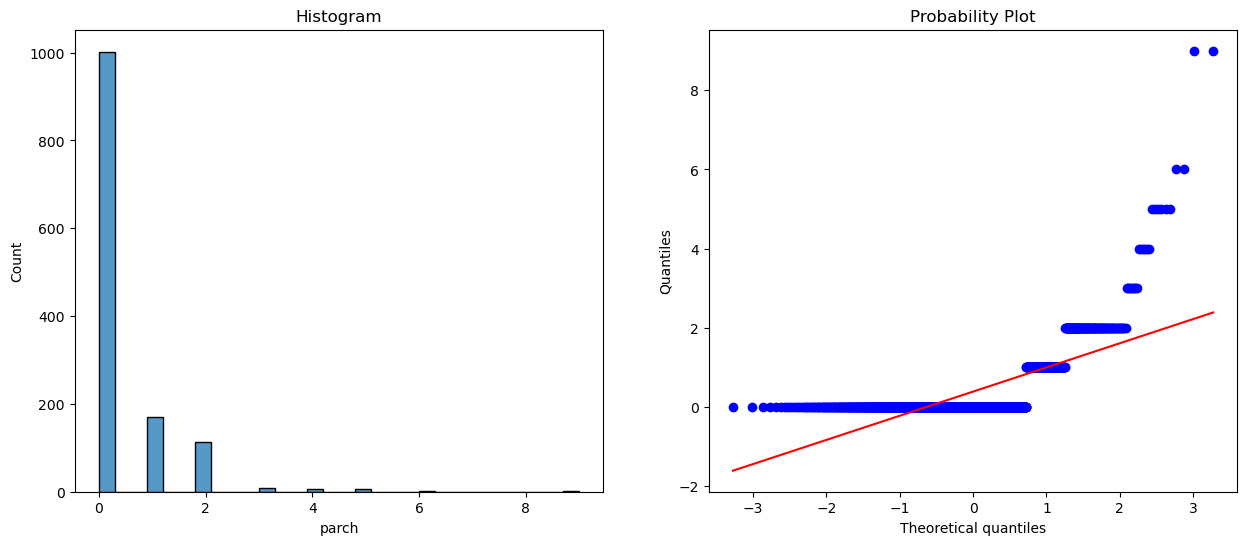

In [148]:
diagnostic_plots(data,'sibsp')
diagnostic_plots(data,'parch') 

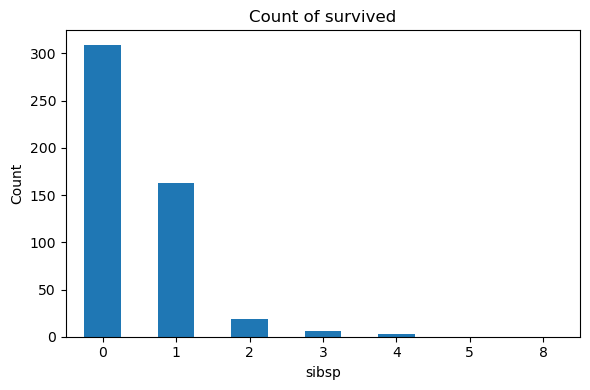

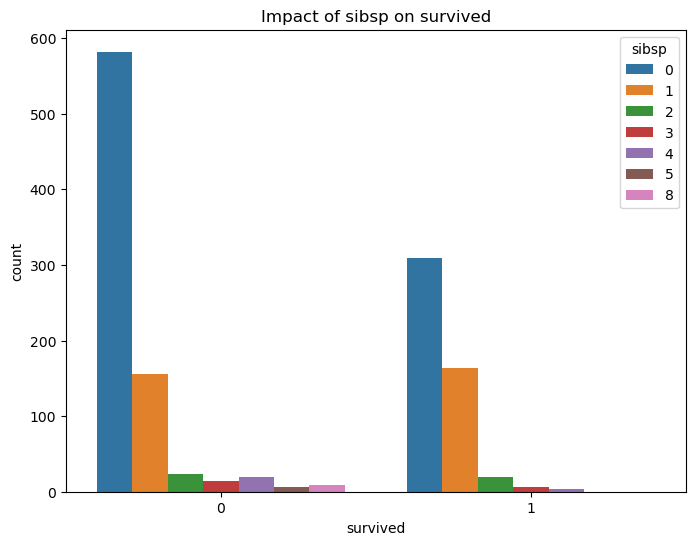

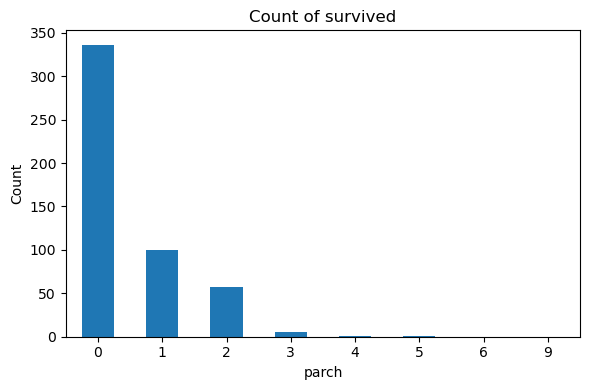

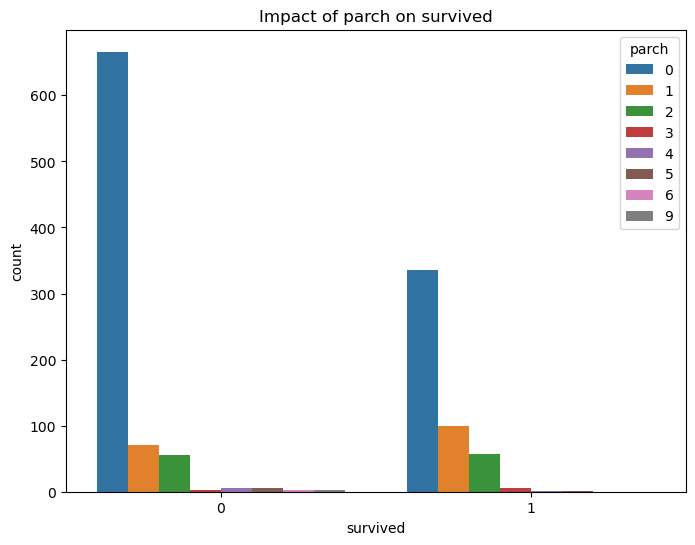

In [149]:
check_groped_target_by_feature(data, 'survived', 'sibsp')
show_impact_subplot(data,'sibsp', 'survived')
check_groped_target_by_feature(data, 'survived', 'parch')
show_impact_subplot(data,'parch', 'survived')

In [150]:
#according to plots and hists we can say that the most people who survived were without family or with less 
#both of features represent almost the same information about of number of family members
# So in purpose of reduse dataset size need to create FAMILY variable
#by sum of 'sibsp', 'parch' and drop them
data['family'] = data['sibsp'] +data['parch']
data.drop(['sibsp', 'parch'], axis = 1, inplace= True)
data.head(3)

,pclass,survived,sex,age,ticket,fare,cabin,embarked,boat,family
0,1,1,female,29.0000,24160,211.3375,B5,S,2,0
1,1,1,male,0.9167,113781,151.5500,C22,S,11,3
2,1,0,female,2.0000,113781,151.5500,C22,S,NaN,3


As we can see more people survived who was alone. So we able implement Rare labels encoding(in encoding section) (less than 5%) and other categories encode with OneHotEncoding. But it will expand feature space.
So I think enough information for us going to be 1 or 0 value for family/alone respectively

In [151]:
data['fam'] = np.where(data['family'] ==0,0,1)
data.drop('family', axis= 1,inplace= True)
data.head(3)

,pclass,survived,sex,age,ticket,fare,cabin,embarked,boat,fam
0,1,1,female,29.0000,24160,211.3375,B5,S,2,0
1,1,1,male,0.9167,113781,151.5500,C22,S,11,1
2,1,0,female,2.0000,113781,151.5500,C22,S,NaN,1


###### Mixed variables cabin and ticket

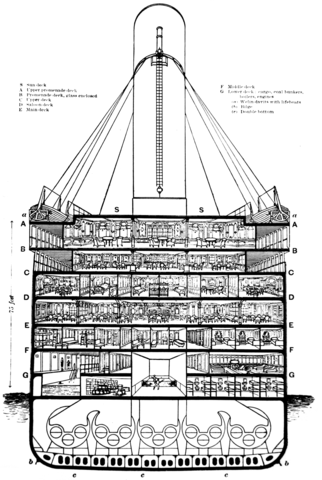

In [152]:
immage_sor='../titanic/Titanic_cabin.png'

display(Image(filename = immage_sor))

In [153]:
data['cabin_num'] = data['cabin'].str.extract('(\d+)')# extract first label from variable 'cabin'

data['cabin_cat'] = data['cabin'].str[0] # simplify the categorical variable to prepare the data for modeling. 

data[['cabin','cabin_cat','cabin_num']].head(10)

,cabin,cabin_cat,cabin_num
0,B5,B,5
1,C22,C,22
2,C22,C,22
3,C22,C,22
4,C22,C,22
5,E12,E,12
6,D7,D,7
7,A36,A,36
8,C101,C,101
9,NaN,NaN,NaN


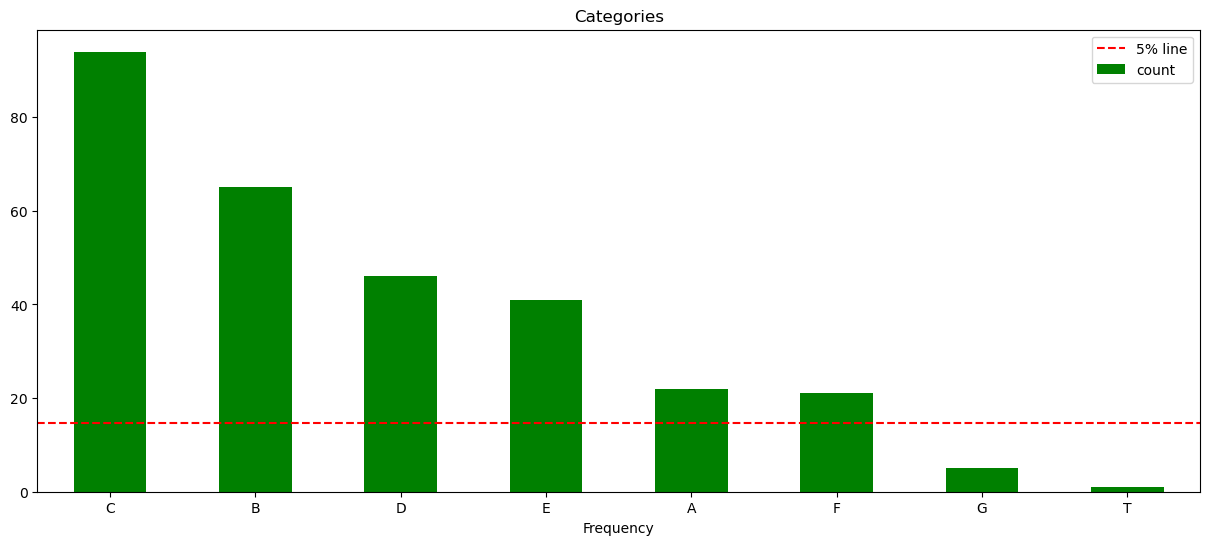

In [154]:
categorical_plot(data,'cabin_cat') 

In [155]:
#from the plot we can see that C is the frequent category
#also lets check theory that pclass and cabin_cat shows us almost the same infornation or
#cabin_cat doesnt give us any information that influence our target at all
pd.concat([data,data['pclass']], axis = 1).groupby('cabin_cat')['pclass'].mean()

,pclass,pclass
cabin_cat,,
A,1.000000,1.000000
B,1.000000,1.000000
C,1.000000,1.000000
D,1.130435,1.130435
E,1.243902,1.243902
F,2.380952,2.380952
G,3.000000,3.000000
T,1.000000,1.000000


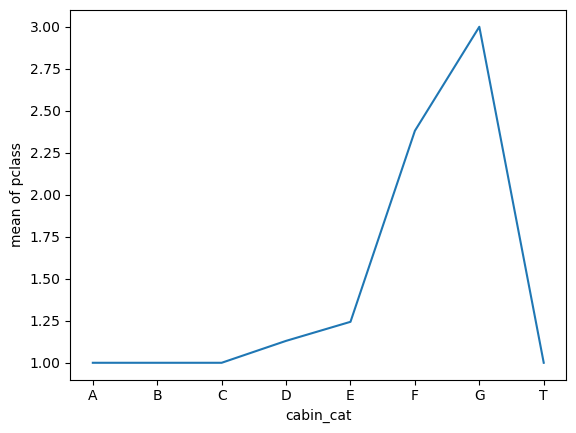

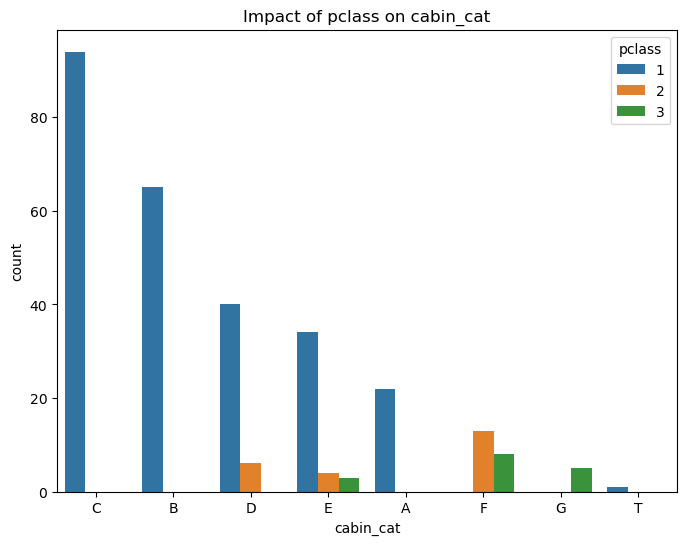

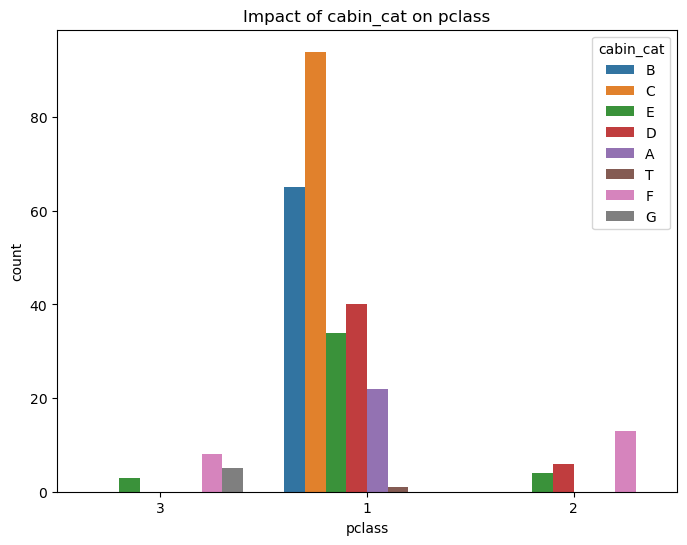

In [156]:
show_grouped_plot(data,data['survived'],'cabin_cat','pclass')
show_impact_subplot(data, 'pclass', 'cabin_cat')
show_impact_subplot(data, 'cabin_cat','pclass')

In [157]:
data['cabin_cat'].isnull().mean()*100

77.46371275783041

In [158]:
#According to Titanic deck description it was 
#Passenger Desk from A to G
#And T category it was TopTank deck On the Titanic, it housed the engines and boiler rooms that is why 
#its like 1st class

#from this tab we clearly can see relationships between pclass and cabin_category

In [159]:
#lets check relationships between target and cabin_cat
pd.concat([data,data['survived']], axis = 1).groupby('cabin_cat')['survived'].mean()

,survived,survived
cabin_cat,,
A,0.500000,0.500000
B,0.723077,0.723077
C,0.606383,0.606383
D,0.695652,0.695652
E,0.731707,0.731707
F,0.619048,0.619048
G,0.600000,0.600000
T,0.000000,0.000000


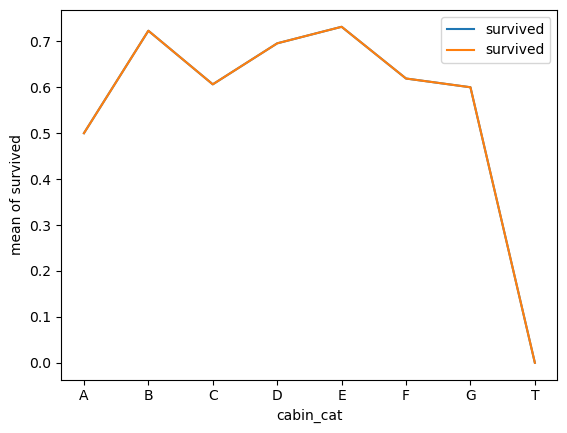

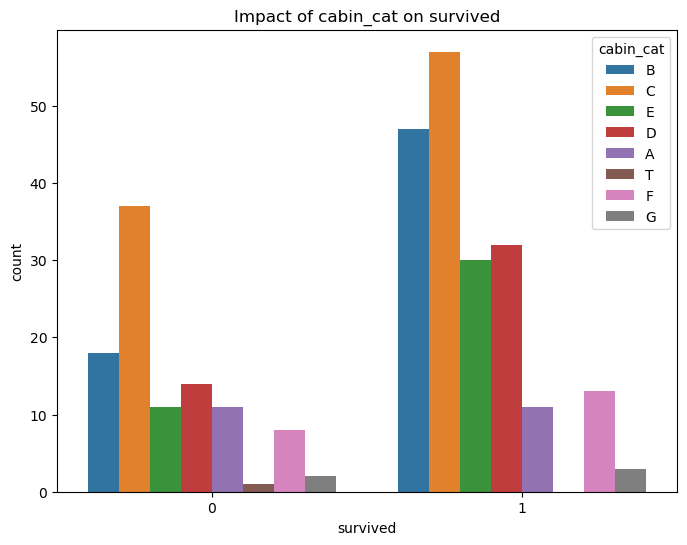

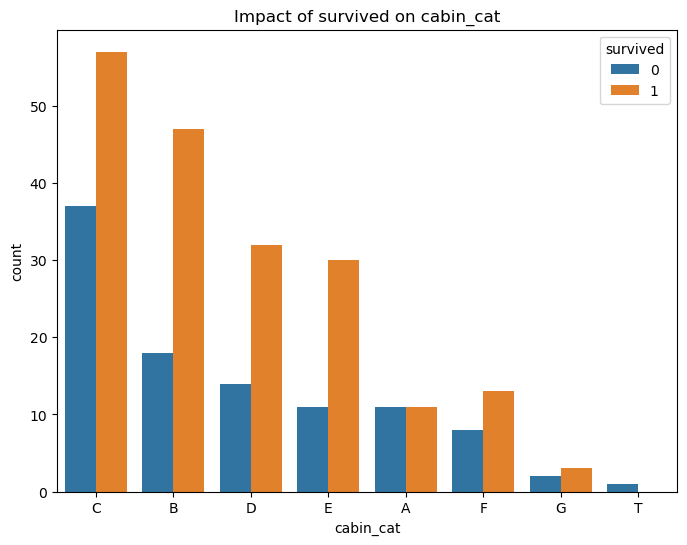

In [160]:
show_grouped_plot(data,data['survived'],'cabin_cat','survived')
show_impact_subplot(data,'cabin_cat', 'survived')
show_impact_subplot(data,'survived','cabin_cat')

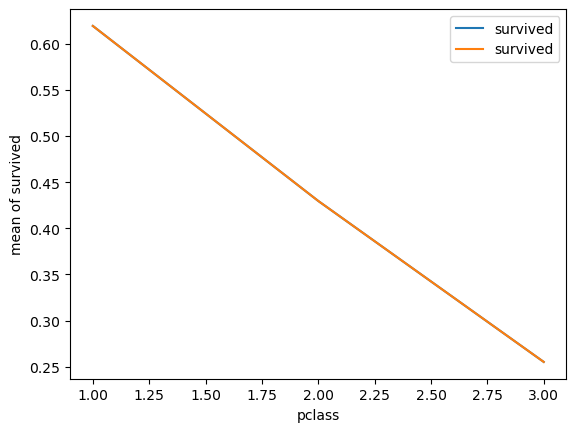

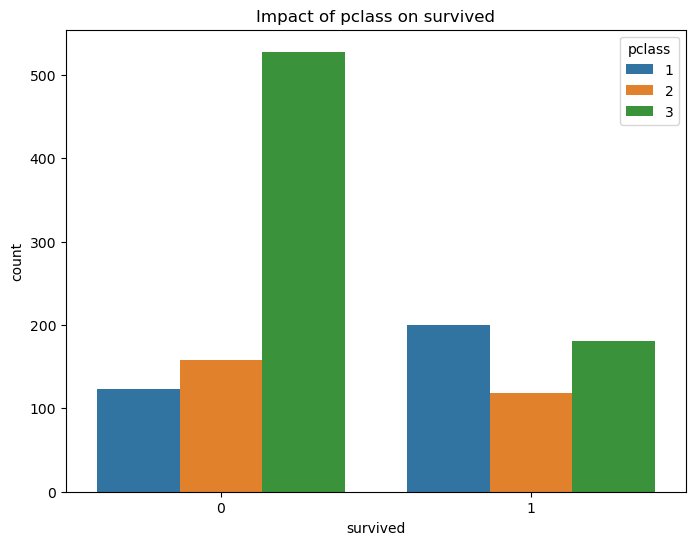

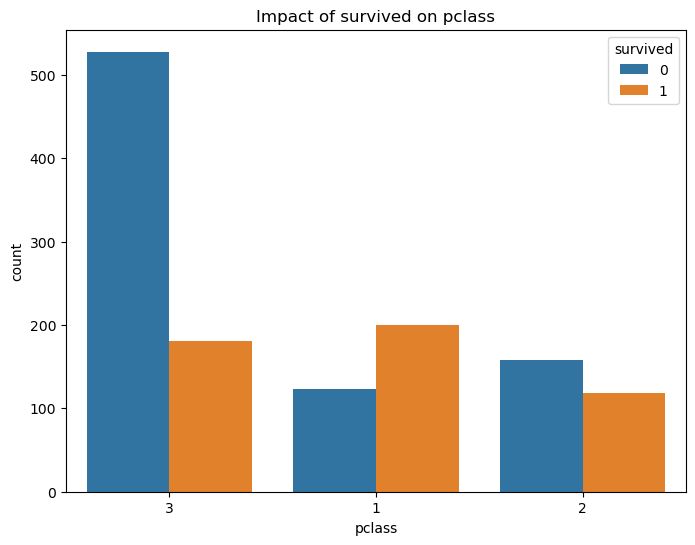

In [161]:
#lets check relationships between target and pclass
show_grouped_plot(data,data['survived'],'pclass','survived')
show_impact_subplot(data,'pclass', 'survived')
show_impact_subplot(data,'survived','pclass')

In [162]:
#So we clearly can see that pclass its give us almost the same information that cabin_category
#We can see that most passenger survived from 1st class "pclass" and its A,B,C category from "cabin_category"
# Also if we will leave cabin_category it will expand dataset after feature encoding and as we know 
#its not good for tree based alhorithms
#Plus there is 77.4% of missing values in cabin_category which is definetely will distort the feature 
#after imputation

#So dropping all the features about cabin
data.drop(['cabin', 'cabin_num','cabin_cat'], axis = 1, inplace= True)
data.head(3)

,pclass,survived,sex,age,ticket,fare,embarked,boat,fam
0,1,1,female,29.0000,24160,211.3375,S,2,0
1,1,1,male,0.9167,113781,151.5500,S,11,1
2,1,0,female,2.0000,113781,151.5500,S,NaN,1


In [163]:
#ticket
data['ticket'].isnull().mean()

0.0

In [164]:
data['ticket_num'] = data['ticket'].str.extract('(\d+)')
data['ticket_num'] = data['ticket_num'].astype('float')

data['ticket_num'].isnull().mean()*100,data['ticket_num'].nunique() 

(0.30557677616501144, 864)

In [165]:
#featuring Ticket varibles without missing data gives us missing data in new variable 'ticket_num' 
#and not really redusing cardinality of variable
#my own opinion that now we definetely have to drop it because ticket number doesnt really influence on
#the fact of surviving

#The more information we can get from pclass. Because it is show us 
#how far was passenger from lifeboats (I mean level of Titanic construction)

data.drop(['ticket', 'ticket_num'], axis= 1, inplace=True)
data.head(3)

,pclass,survived,sex,age,fare,embarked,boat,fam
0,1,1,female,29.0000,211.3375,S,2,0
1,1,1,male,0.9167,151.5500,S,11,1
2,1,0,female,2.0000,151.5500,S,NaN,1


### Visualization of the Embarkation
Reffered from http://gisdatascience.com/spatial-data-visualization-in-python, titanic embarked ports are visualized on geo map.

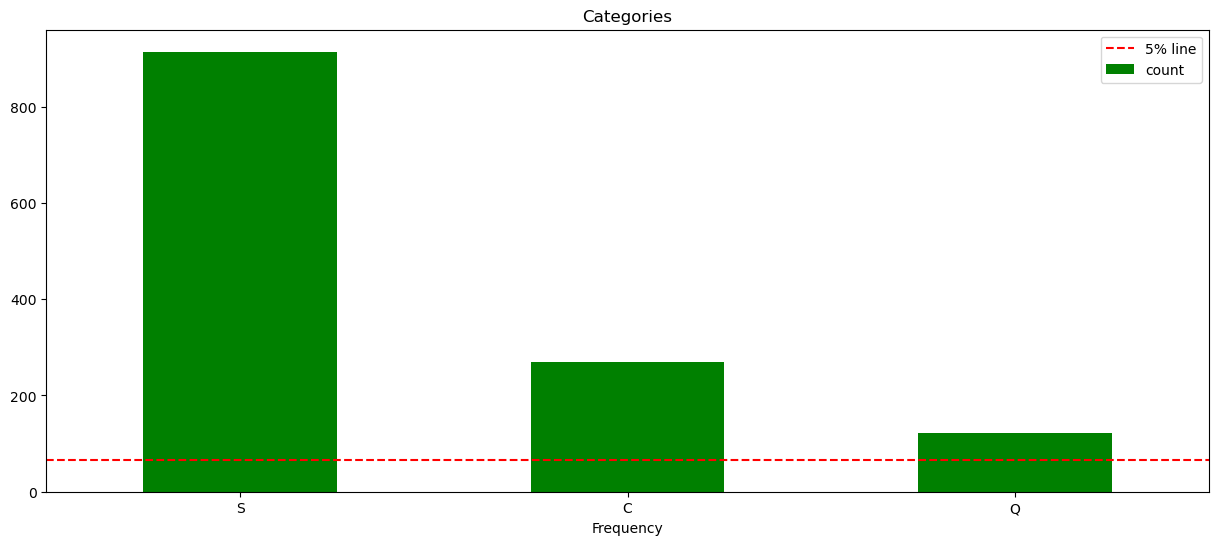

In [166]:
categorical_plot(data,'embarked')

In [167]:
# C = Cherbourg, Q = Queenstown, S = Southampton

###### Boat

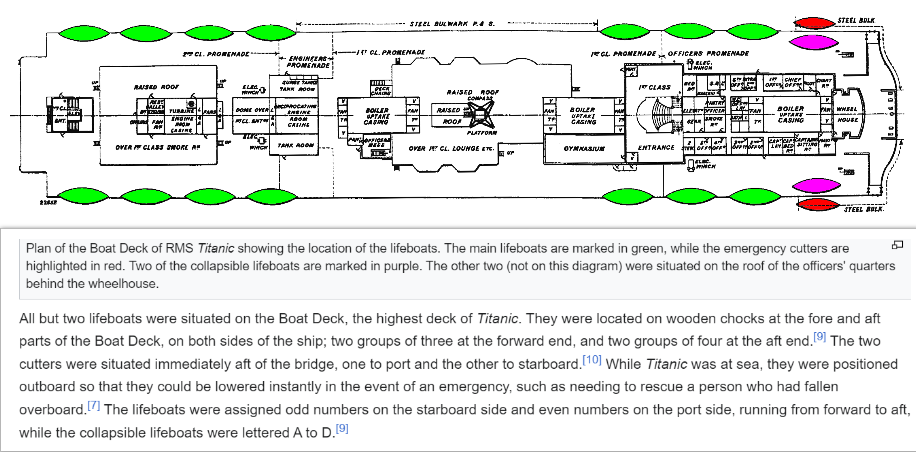

In [168]:
immage_sor='../titanic/titanic_scheme.png'

display(Image(filename = immage_sor))

In [169]:
data['boat'].unique(), data['boat'].isnull().mean()*100 #almost 63% of missing values

(array(['2', '11', nan, '3', '10', 'D', '4', '9', '6', 'B', '8', 'A', '5',
        '7', 'C', '14', '5 9', '13', '1', '15', '5 7', '8 10', '12', '16',
        '13 15 B', 'C D', '15 16', '13 15'], dtype=object),
 62.87242169595111)

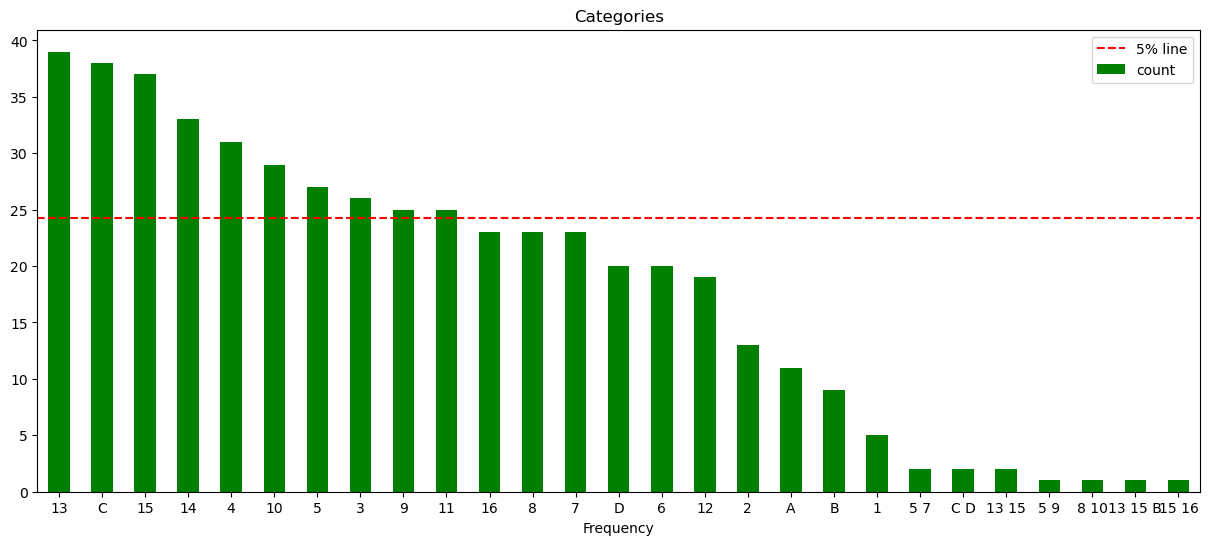

In [170]:
categorical_plot(data,'boat')

According to information about missing values and 
looks like The number of lifeboat doesnt really influence on our traget
and we can drop it
because there is a lot of missing value and even if we are going to impute it and then encode with RareLabels
there is all labels are rare
So I think enough information for us going to be 1 or 0 value for any number of boat/missing value respectively
and then check the relationship between boat anf target variable

In [171]:
data['boat_info'] = np.where(pd.isnull(data['boat']),0,1)
#and we can drop boat feature
data.drop('boat', axis=1, inplace= True)
data.head(3)

,pclass,survived,sex,age,fare,embarked,fam,boat_info
0,1,1,female,29.0000,211.3375,S,0,1
1,1,1,male,0.9167,151.5500,S,1,1
2,1,0,female,2.0000,151.5500,S,1,0


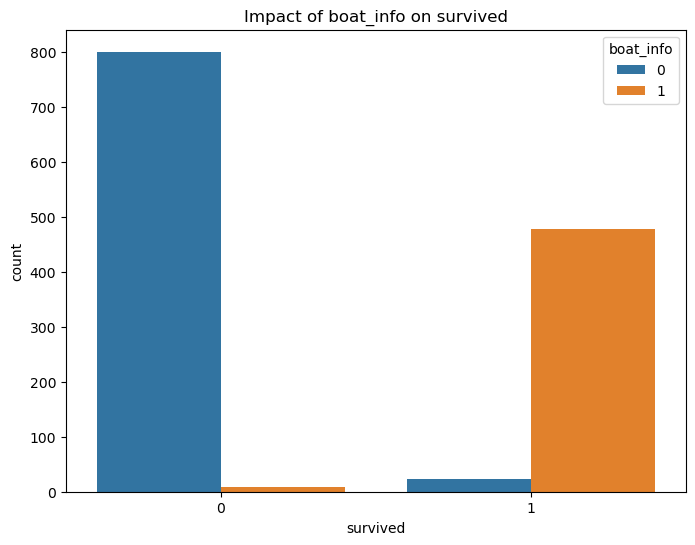

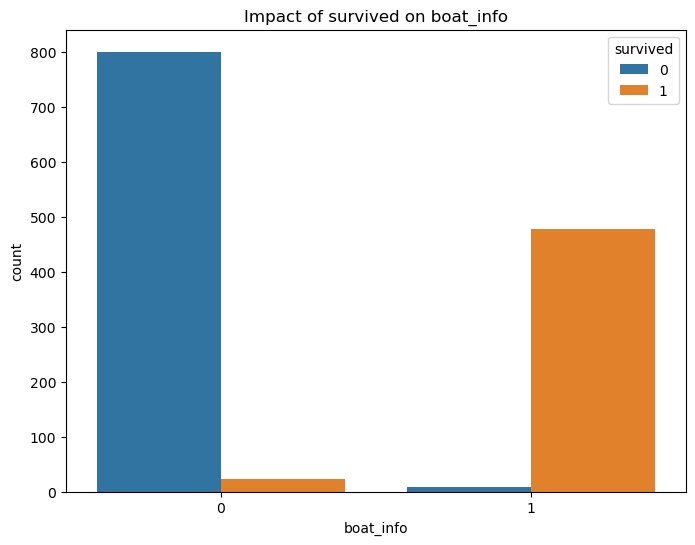

In [172]:
show_impact_subplot(data,'boat_info', 'survived')
show_impact_subplot(data,'survived','boat_info')

In [173]:
data.head(3)
data_for_corr = data.drop(['pclass','sex','age','fare','embarked'], axis = 1)
data_for_corr
corr = data_for_corr.corr()
corr

,survived,fam,boat_info
survived,1.000000,0.201719,0.948190
fam,0.201719,1.000000,0.207868
boat_info,0.948190,0.207868,1.000000


In [174]:
#data.drop('boat_info', axis = 1, inplace= True) 
#let's not drop this feature till the model training

In [175]:
#before data imputation lets redifine variables after manipulation
discrete = [var for var in data.columns if data[var].dtypes != 'O' and var != 'survived' and data[var].nunique() < 10]
continous = [var for var in data.columns if data[var].dtypes != 'O' and var != 'survived' and var not in discrete]
categorical = [var for var in data.columns if data[var].dtypes == 'O' and var != 'survived' ]

## Preparing data for data featuring

In [176]:
data.isnull().mean()*100

pclass        0.000000
survived      0.000000
sex           0.000000
age          20.091673
fare          0.076394
embarked      0.152788
fam           0.000000
boat_info     0.000000
dtype: float64

In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('survived', axis = 1),
    data['survived'],
    test_size= 0.3,
    random_state= 0
)

X_train.shape, X_test.shape

((916, 7), (393, 7))

In [178]:
X_train

,pclass,sex,age,fare,embarked,fam,boat_info
501,2,female,13.0000,19.5000,S,1,1
588,2,female,4.0000,23.0000,S,1,1
402,2,female,30.0000,13.8583,C,1,1
1193,3,male,NaN,7.7250,Q,0,0
686,3,female,22.0000,7.7250,Q,0,1
...,...,...,...,...,...,...,...
763,3,female,0.1667,20.5750,S,1,1
835,3,male,NaN,8.0500,S,0,0
1216,3,female,NaN,7.7333,Q,0,1
559,2,female,20.0000,36.7500,S,0,1


## Missing data imputation

## Mean median imputer

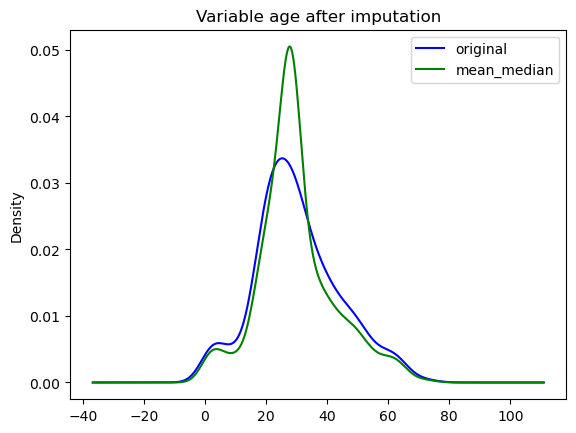

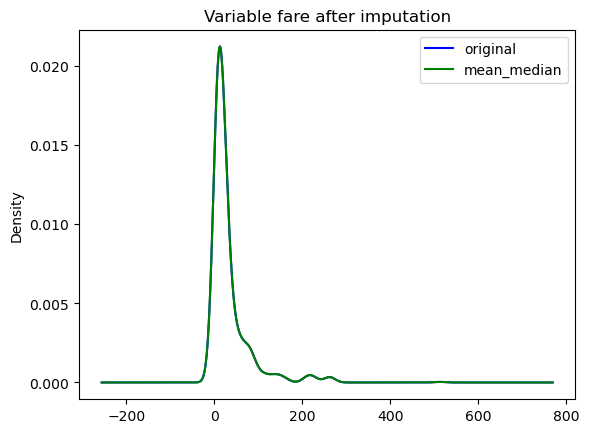

Variance of age before imputation: 194.16304666581863 and after :157.79842957602128
Variance of fare before imputation: 2248.326728972295 and after :2248.326728972295


In [179]:
# mean median 
X_train_mean_median = X_train.copy()
imputer = MeanMedianImputer(imputation_method= 'median', variables= continous )
imputer.fit(X_train_mean_median)
X_train_mean_median = imputer.transform(X_train_mean_median)

for var in imputer.variables_:
    subplot(X_train, X_train_mean_median, var, 'mean_median')
    
for var in imputer.variables_:
    print_variance_of_method(X_train, X_train_mean_median, var)

In [180]:
# age not sure, will try another methods
#for fare mean_median is also ok

## Random sample imputer

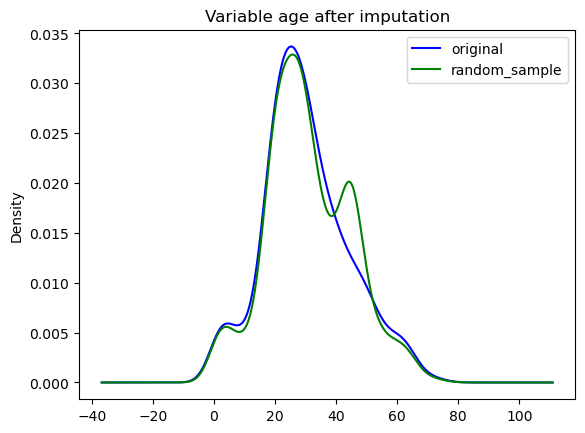

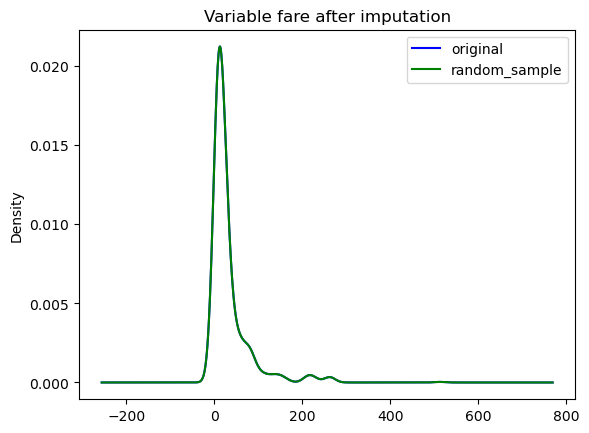

Variance of age before imputation: 194.16304666581863 and after :189.5823869101182
Variance of fare before imputation: 2248.326728972295 and after :2248.326728972295


In [181]:
X_train_random_sample = X_train.copy()
rs_imputer = RandomSampleImputer(
    random_state= ['age','fare'],
    seed = 'observation',
    seeding_method = 'add',
    variables= continous
)

rs_imputer.fit(X_train_random_sample)
X_train_random_sample = rs_imputer.transform(X_train_random_sample)

for var in continous:
    subplot(X_train, X_train_random_sample, var, 'random_sample')
    
for var in imputer.variables_:
    print_variance_of_method(X_train, X_train_random_sample, var)

In [182]:
# not much better than mean_median for age

## Arbibtrary imputation

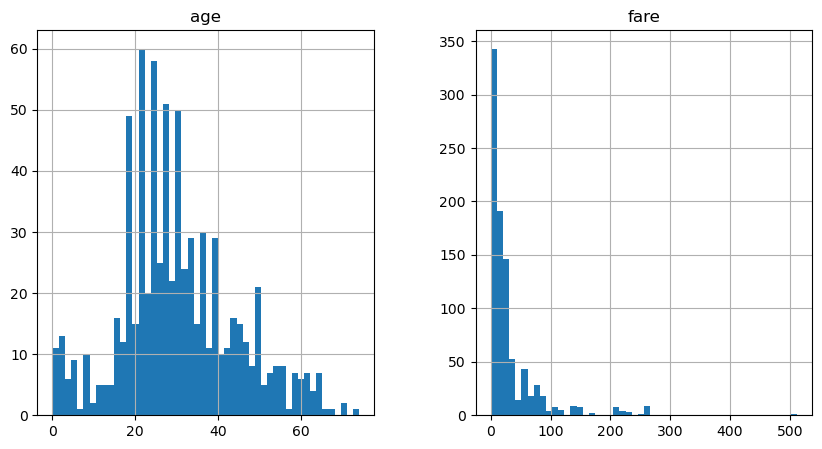

In [183]:
X_train_arbitrary = X_train.copy()
X_train_arbitrary[['age', 'fare']].hist(bins = 50, figsize= (10,5))
plt.show()

In [184]:
#arbitrary_number should be -1 because age and number of cabin starts from 0 according to hist and -1 is closest

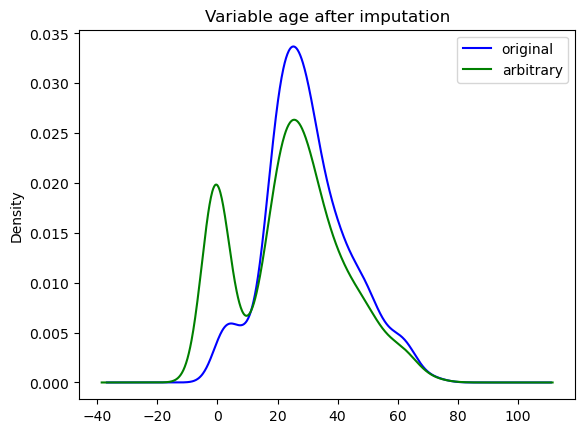

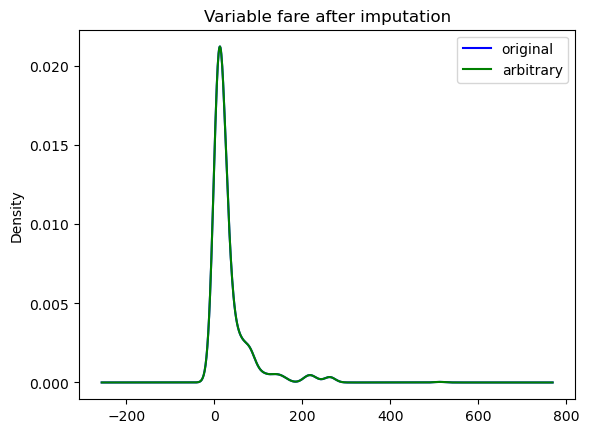

Variance of age before imputation: 194.16304666581863 and after :307.94005269387753
Variance of fare before imputation: 2248.326728972295 and after :2248.326728972295


In [185]:
arb_imputer = ArbitraryNumberImputer(arbitrary_number= -1, variables= continous)
X_train_arbitrary = arb_imputer.fit_transform(X_train_arbitrary)
for var in continous:
    subplot(X_train,X_train_arbitrary, var, 'arbitrary')
    
for var in arb_imputer.variables_:
    print_variance_of_method(X_train, X_train_arbitrary, var)

In [186]:
#guess for age is ok,but not final

## KNN

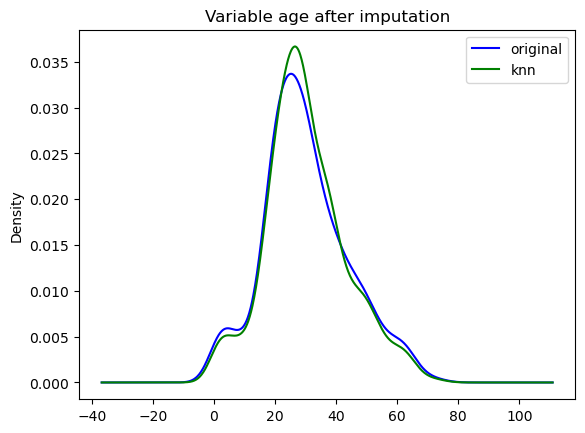

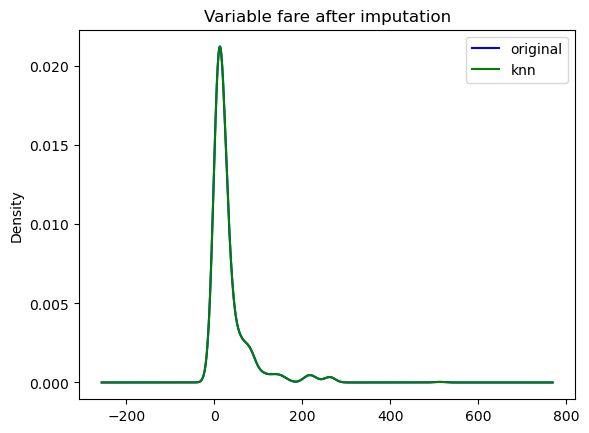

age
original : 194.16304666581863
random_sample : 189.5823869101182
mean_median : 157.79842957602128
arbitrary : 307.94005269387753
knn : 172.74211718105025

fare
original : 2248.326728972295
random_sample : 2248.326728972295
mean_median : 2248.326728972295
arbitrary : 2248.326728972295
knn : 2248.326728972295



In [187]:
X_train_KNN = X_train.copy()
knn_imputer = KNNImputer(
    n_neighbors= 10,
    weights= 'distance',
    metric= 'nan_euclidean',
    add_indicator= False
)

X_train_KNN = knn_imputer.fit_transform(X_train_KNN[continous])
X_train_KNN = pd.DataFrame(X_train_KNN,columns= continous)

for var in continous:
    subplot(X_train, X_train_KNN,var, 'knn')
    
for var in continous:
    print(var)
    print_variance_of_methods(var)
    print()

In [188]:
#for age arbitrary method  is more suitable 
#for fare we can choose any method according to plot, 
#but according to variance looks like arbitrary is the best

## Frequent category imputer

In [189]:
data.select_dtypes(include='O').isnull().mean()*100

sex         0.000000
embarked    0.152788
dtype: float64

In [190]:
#this method can be used only if less that 5% data is missing

In [191]:
X_train_freq_cat= X_train.copy()
X_test_freq_cat= X_test.copy()
cols_to_use = ['embarked']

imputer = CategoricalImputer(imputation_method= 'frequent',variables=cols_to_use)
imputer.fit(X_train_freq_cat)
X_train_freq_cat = imputer.transform(X_test_freq_cat)

imputer.imputer_dict_

{'embarked': 'S'}

In [192]:
# How to check category variables before and after imputation?

In [193]:
X_train['embarked'].value_counts()/ len(X_train)*100, X_train['embarked'].value_counts(), X_train.shape

(embarked
 S    71.179039
 C    19.541485
 Q     9.061135
 Name: count, dtype: float64,
 embarked
 S    652
 C    179
 Q     83
 Name: count, dtype: int64,
 (916, 7))

In [194]:
X_train_freq_cat['embarked'].value_counts()/ len(X_train_freq_cat)*100, X_train_freq_cat['embarked'].value_counts(),X_train_freq_cat.shape

(embarked
 S    66.666667
 C    23.155216
 Q    10.178117
 Name: count, dtype: float64,
 embarked
 S    262
 C     91
 Q     40
 Name: count, dtype: int64,
 (393, 7))

## Random sample imputer

In [195]:
X_train_random_sample_cat = X_train.copy()

imputer = RandomSampleImputer(
    variables= cols_to_use,
    random_state= ['pclass','fam'],
     seed = 'observation',
    seeding_method = 'add'
)

imputer.fit(X_train_random_sample_cat)
X_train_random_sample_cat = imputer.transform(X_train_random_sample_cat)

In [196]:
X_train['embarked'].value_counts()/ len(data)*100

embarked
S    49.809015
C    13.674561
Q     6.340718
Name: count, dtype: float64

In [197]:
X_train_random_sample_cat['embarked'].value_counts()/ len(data)*100

embarked
S    49.961803
C    13.674561
Q     6.340718
Name: count, dtype: float64

## Here is the pipeline of data imputation

In [198]:
imputer_pipe = Pipeline(steps= [
    ('imputer_age', RandomSampleImputer(
            random_state= ['age','fare'],
            seed = 'observation',
            seeding_method = 'add',
            variables= ['age'])),
    ('imputer_fare',ArbitraryNumberImputer(arbitrary_number= -1, variables= ['fare'])),
    ('imputer_cat_embarked',CategoricalImputer(imputation_method= 'frequent',variables= ['embarked']))
])

In [199]:
imputer_pipe.fit(X_train)

X_train_imputed = imputer_pipe.transform(X_train)
X_test_imputed = imputer_pipe.transform(X_test)

X_train_imputed.head(5)

,pclass,sex,age,fare,embarked,fam,boat_info
501,2,female,13.0,19.5000,S,1,1
588,2,female,4.0,23.0000,S,1,1
402,2,female,30.0,13.8583,C,1,1
1193,3,male,45.0,7.7250,Q,0,0
686,3,female,22.0,7.7250,Q,0,1


In [200]:
X_train_imputed.isnull().mean()*100, X_train_imputed.shape

(pclass       0.0
 sex          0.0
 age          0.0
 fare         0.0
 embarked     0.0
 fam          0.0
 boat_info    0.0
 dtype: float64,
 (916, 7))

## Encoding

In [201]:
#lets check what we have in categorical varibles
categorical

['sex', 'embarked']

In [202]:
#actually pclass is also categorical,so we need to transform it from discrete(int), to object
X_train_imputed['pclass'] = X_train_imputed['pclass'] .astype('O')
X_test_imputed['pclass'] = X_test_imputed['pclass'] .astype('O')
X_train_imputed.dtypes, X_test_imputed.dtypes

(pclass        object
 sex           object
 age          float64
 fare         float64
 embarked      object
 fam            int64
 boat_info      int64
 dtype: object,
 pclass        object
 sex           object
 age          float64
 fare         float64
 embarked      object
 fam            int64
 boat_info      int64
 dtype: object)

In [203]:
#we have not high cardinality of categorical variables so lets use OHE
encoder = OneHotEncoder(
   top_categories= None,
    variables=['sex', 'embarked', 'pclass'],
    drop_last= True
)
# drop_last = True to not expand dataset
encoder.fit(X_train_imputed)

OneHotEncoder(drop_last=True, variables=['sex', 'embarked', 'pclass'])

In [204]:
encoder.encoder_dict_

{'sex': ['female'], 'embarked': ['S', 'C'], 'pclass': [2, 3]}

In [205]:
X_train_imputed_encoded= encoder.transform(X_train_imputed)
X_test_imputed_encoded= encoder.transform(X_test_imputed)

X_train_imputed_encoded.shape, X_test_imputed_encoded.shape

((916, 9), (393, 9))

In [206]:
X_train_imputed_encoded.head(3)

,age,fare,fam,boat_info,sex_female,embarked_S,embarked_C,pclass_2,pclass_3
501,13.0,19.5000,1,1,1,1,0,1,0
588,4.0,23.0000,1,1,1,1,0,1,0
402,30.0,13.8583,1,1,1,0,1,1,0


## Discretisation of continuous variables (age and fare)
### Equal frequency discretisation with Feature-Engine

In [207]:
disc = EqualFrequencyDiscretiser(
    q = 10,
    variables= ['age', 'fare'],
    return_object= True
)

disc.fit(X_train_imputed_encoded)
X_train_EqFrDisc = disc.transform(X_train_imputed_encoded)
X_test_EqFrDisc = disc.transform(X_test_imputed_encoded)

X_train_EqFrDisc.dtypes

age           object
fare          object
fam            int64
boat_info      int64
sex_female     int64
embarked_S     int64
embarked_C     int64
pclass_2       int64
pclass_3       int64
dtype: object

In [208]:
X_train_EqFrDisc.head(3)

,age,fare,fam,boat_info,sex_female,embarked_S,embarked_C,pclass_2,pclass_3
501,0,5,1,1,1,1,0,1,0
588,0,6,1,1,1,1,0,1,0
402,5,4,1,1,1,0,1,1,0


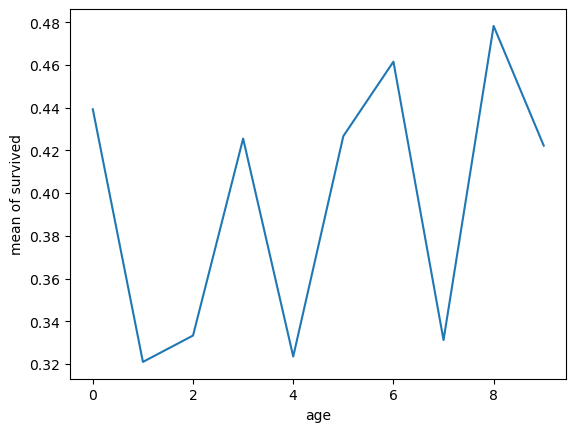

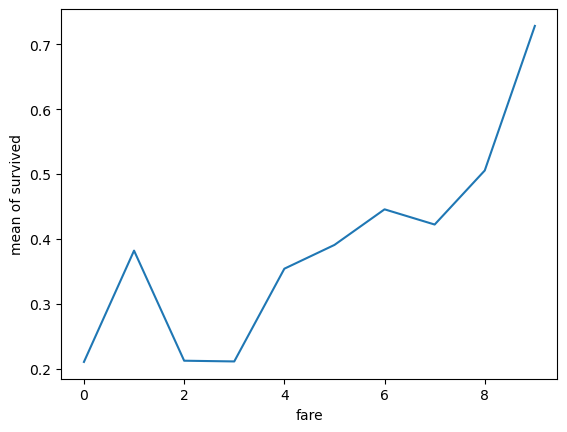

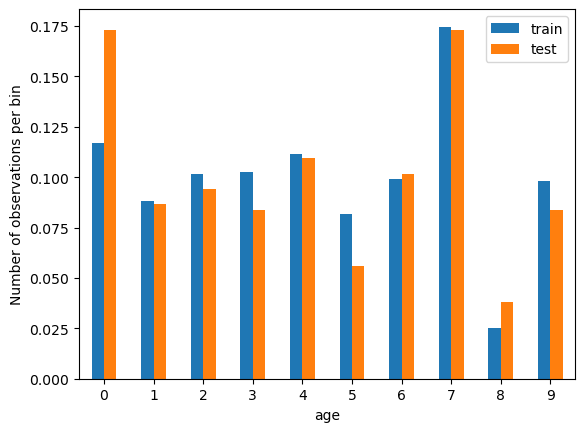

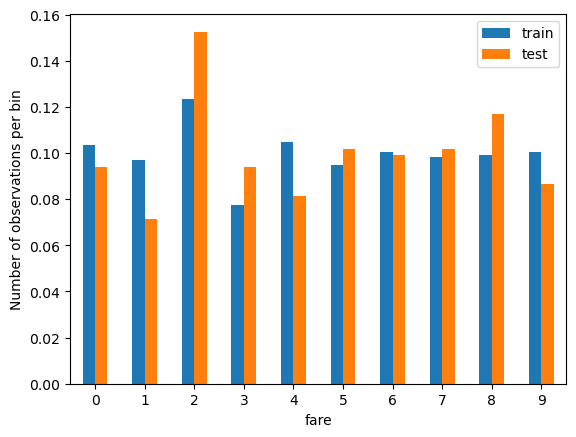

In [209]:
show_grouped_plot(X_train_EqFrDisc,y_train,'age', 'survived')
show_grouped_plot(X_train_EqFrDisc,y_train,'fare', 'survived')
check_balance_of_discretized(X_train_EqFrDisc, X_test_EqFrDisc, 'age')
check_balance_of_discretized(X_train_EqFrDisc, X_test_EqFrDisc, 'fare')  

In [210]:
# doesnt look like monotonic relationship

### Ordinal encoding with Feature-Engine

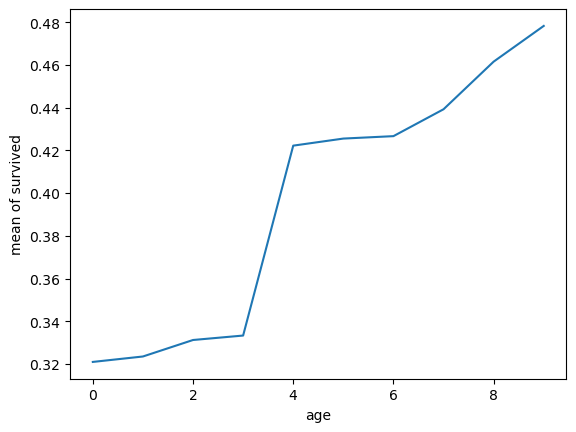

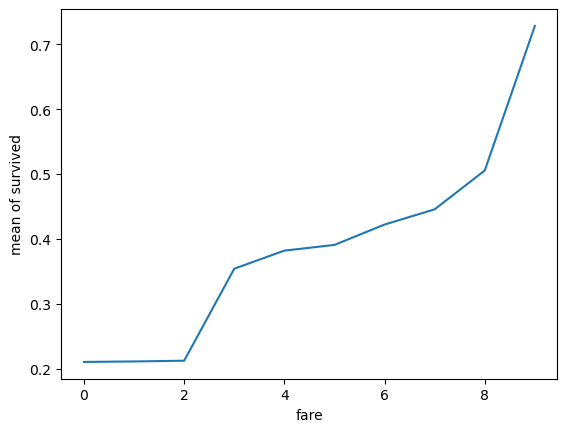

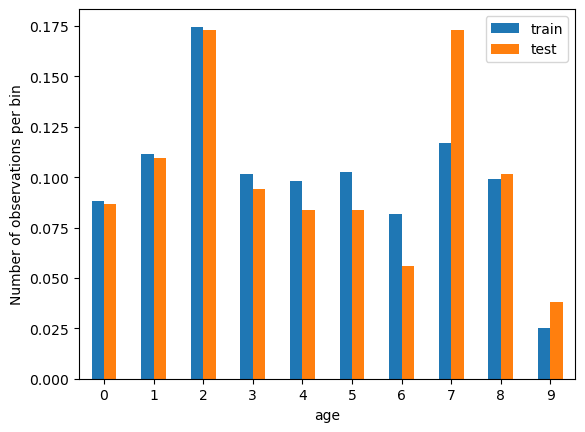

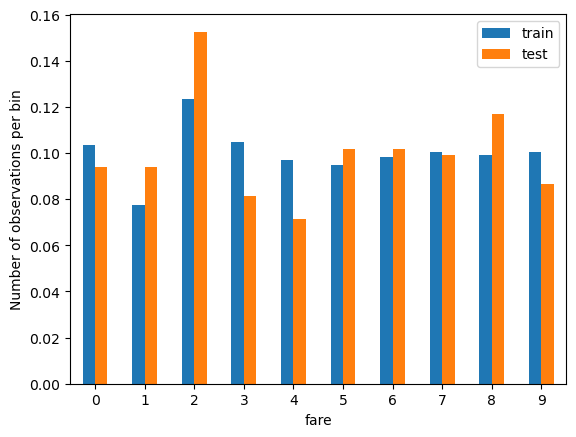

In [211]:
X_train_OrdinalEnc_disc = X_train_EqFrDisc.copy()
X_test_OrdinalEnc_disc = X_test_EqFrDisc.copy()

enc = OrdinalEncoder(
    encoding_method= 'ordered'
)

enc.fit(X_train_OrdinalEnc_disc, y_train)

X_train_OrdinalEnc_disc = enc.transform(X_train_OrdinalEnc_disc)
X_test_OrdinalEnc_disc = enc.transform(X_test_OrdinalEnc_disc)

show_grouped_plot(X_train_OrdinalEnc_disc,y_train,'age', 'survived')
show_grouped_plot(X_train_OrdinalEnc_disc,y_train,'fare', 'survived')
check_balance_of_discretized(X_train_OrdinalEnc_disc, X_test_OrdinalEnc_disc, 'age')
check_balance_of_discretized(X_train_OrdinalEnc_disc, X_test_OrdinalEnc_disc, 'fare')  

In [212]:
# look like this method of discretisation fits after Equal frequency discretisation with Feature-Engine

### DecisionTreeDiscretiser

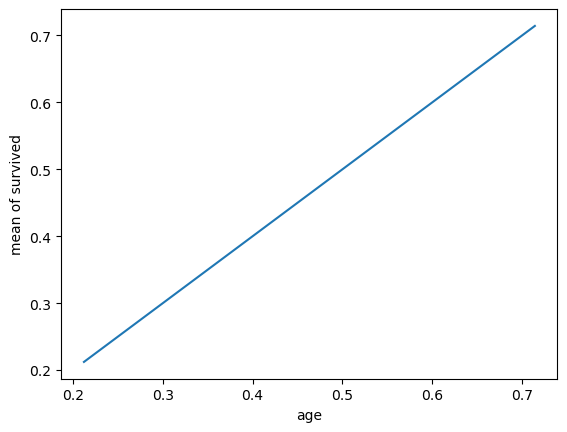

Monotonic relationship between discretised age and target TRAIN_set


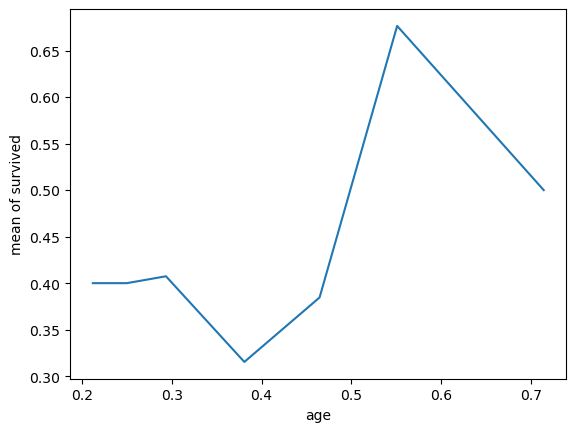

Monotonic relationship between discretised age and target TEST_set


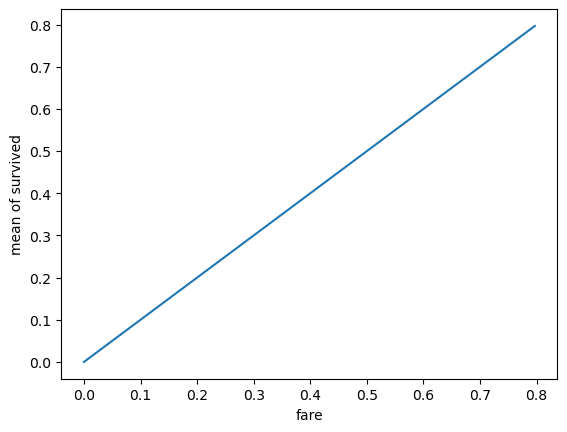

Monotonic relationship between discretised fare and target TRAIN_set


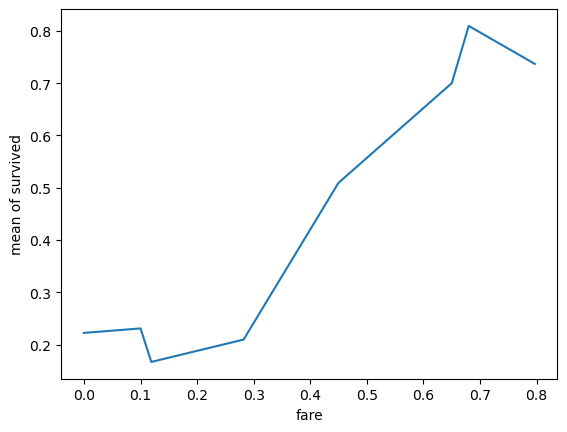

Monotonic relationship between discretised fare and target TEST_set


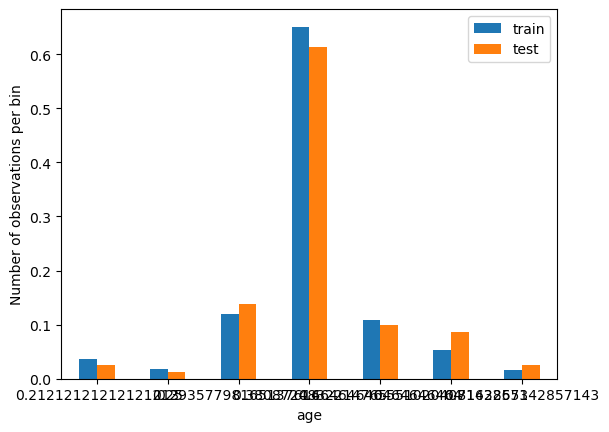

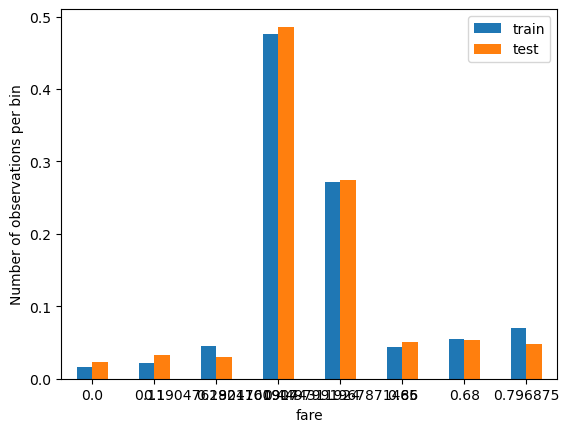

In [213]:
treeDisc = DecisionTreeDiscretiser(
    cv = 10,
    scoring= 'accuracy',
    variables= ['age', 'fare'],
    regression= False,
    param_grid= {
        'max_depth':[1,2,3],
        'min_samples_leaf':[10,4]
    }
)

treeDisc.fit(X_train_imputed_encoded, y_train)
X_train_DecTree_disc = treeDisc.transform(X_train_imputed_encoded)
X_test_DecTree_disc = treeDisc.transform(X_test_imputed_encoded)

show_grouped_plot(X_train_DecTree_disc,y_train,'age', 'survived')
print('Monotonic relationship between discretised age and target TRAIN_set')
show_grouped_plot(X_test_DecTree_disc,y_test,'age', 'survived')
print('Monotonic relationship between discretised age and target TEST_set')

show_grouped_plot(X_train_DecTree_disc,y_train,'fare', 'survived')
print('Monotonic relationship between discretised fare and target TRAIN_set')
show_grouped_plot(X_test_DecTree_disc,y_test,'fare', 'survived')
print('Monotonic relationship between discretised fare and target TEST_set')

check_balance_of_discretized(X_train_DecTree_disc, X_test_DecTree_disc, 'age')
check_balance_of_discretized(X_train_DecTree_disc, X_test_DecTree_disc, 'fare')

In [214]:
#looks like this method of discretisation give us monotonic relationship comparing to previous methods

### DecisionTreeDiscretiser we can implement according to plots

In [215]:
treeDisc = DecisionTreeDiscretiser(
    cv = 10,
    scoring= 'accuracy',
    variables= ['age', 'fare'],
    regression= False,
    param_grid= {
        'max_depth':[1,2,3],
        'min_samples_leaf':[10,4]
    }
)

treeDisc.fit(X_train_imputed_encoded, y_train)
X_train_imp_enc_disc = treeDisc.transform(X_train_imputed_encoded)
X_test_imp_enc_disc = treeDisc.transform(X_test_imputed_encoded)

X_train_imp_enc_disc['age'].unique(),X_train_imp_enc_disc['fare'].unique()

(array([0.71428571, 0.55102041, 0.38087248, 0.46464646, 0.29357798,
        0.21212121, 0.25      ]),
 array([0.4497992 , 0.28211009, 0.68      , 0.796875  , 0.65      ,
        0.1       , 0.11904762, 0.        ]))

In [216]:
X_train_imp_enc_disc.head(3)

,age,fare,fam,boat_info,sex_female,embarked_S,embarked_C,pclass_2,pclass_3
501,0.714286,0.449799,1,1,1,1,0,1,0
588,0.551020,0.449799,1,1,1,1,0,1,0
402,0.380872,0.282110,1,1,1,0,1,1,0


# Features Selection

In [217]:
X_train_original = X_train_imp_enc_disc.copy()
X_test_original = X_test_imp_enc_disc.copy()
X_train_imp_enc_disc.shape, X_test_imp_enc_disc.shape

((916, 9), (393, 9))

### Remove constant features

In [218]:
constant_features = [
    feat for feat in X_train_imp_enc_disc.columns if X_train_imp_enc_disc[feat].std() == 0
]

X_train_imp_enc_disc.drop(labels= constant_features, axis= 1, inplace= True)
X_test_imp_enc_disc.drop(labels= constant_features, axis= 1, inplace= True)

X_train_imp_enc_disc.shape, X_test_imp_enc_disc.shape #empty

((916, 9), (393, 9))

### Remove quasi-constant features

In [219]:
sel = VarianceThreshold(threshold= 0.01)
sel.fit(X_train_imp_enc_disc)

sum(sel.get_support())
quasi_constant = X_train_imp_enc_disc.columns[~sel.get_support()]
features_to_keep = X_train_imp_enc_disc.columns[sel.get_support()]

len(quasi_constant), quasi_constant

X_train_qasi_const_feat = sel.transform(X_train_imp_enc_disc)
X_test_qasi_const_feat = sel.transform(X_test_imp_enc_disc)

X_train_qasi_const_feat = pd.DataFrame(X_train_qasi_const_feat)
X_train_qasi_const_feat.columns = features_to_keep

X_test_qasi_const_feat = pd.DataFrame(X_test_qasi_const_feat)
X_test_qasi_const_feat.columns = features_to_keep


X_train_qasi_const_feat

,fare,fam,boat_info,sex_female,embarked_S,embarked_C,pclass_2,pclass_3
0,0.449799,1.0,1.0,1.0,1.0,0.0,1.0,0.0
1,0.449799,1.0,1.0,1.0,1.0,0.0,1.0,0.0
2,0.282110,1.0,1.0,1.0,0.0,1.0,1.0,0.0
3,0.282110,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.282110,0.0,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
911,0.449799,1.0,1.0,1.0,1.0,0.0,0.0,1.0
912,0.282110,0.0,0.0,0.0,1.0,0.0,0.0,1.0
913,0.282110,0.0,1.0,1.0,0.0,0.0,0.0,1.0
914,0.449799,0.0,1.0,1.0,1.0,0.0,1.0,0.0


### Remove duplicated features

In [220]:
duplicated_feat = []
for i in range(0, len(X_train_imp_enc_disc.columns)):
    if i% 10 == 0:
        print(i)
    col_1 = X_train_imp_enc_disc.columns[i]
    
    for col_2 in X_train_imp_enc_disc.columns[i+1:]:
        if X_train_imp_enc_disc[col_1].equals(X_train_imp_enc_disc[col_2]):
            duplicated_feat.append(col_2)

len(duplicated_feat)
duplicated_feat #empty

0


[]

### Remove correlated features

In [221]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i] #берем имя колонки точно!не столбца
                col_corr.add(colname)
                
    return col_corr

In [222]:
corr_features = correlation(X_train_imp_enc_disc, 0.8)
print("Correlated features: ",len(set(corr_features))) #empty

Correlated features:  0


### Select features based on Anova

In [223]:
sel_ = SelectKBest(k = 'all')
sel_.fit(X_train_imp_enc_disc, y_train)

features_to_keep = X_train_imp_enc_disc.columns[sel_.get_support()]
len( X_train_imp_enc_disc.columns[~sel_.get_support()]) #empty

0

# Ready to train

## Decision tree

In [224]:
def run_DecisionTreeClassifier(X_train, X_test, y_train, y_test):
    classifier = DecisionTreeClassifier(criterion= 'entropy', random_state= 0)
    classifier.fit(X_train, y_train)

    print('Decision tree')
    print('Train set')
    pred = classifier.predict_proba(X_train)
    print('Decision tree roc-auc: {}'.format(roc_auc_score(y_train,pred[:,1])))
    print()
    print('Test set')
    pred = classifier.predict_proba(X_test)
    print('Decision tree roc-auc: {}'.format(roc_auc_score(y_test,pred[:,1])))
    print()
    
   
    parameters = {
              'max_depth' : [2,4,6,8,10,12],
              'criterion' :['gini', 'entropy','log_loss']
             }
    

    grid_search = GridSearchCV(
    estimator = classifier, 
    param_grid = parameters,
    scoring = 'accuracy',
    cv = 10,
    n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_
    

## Random Forest

In [225]:
def run_RandomForestClassifier(X_train, X_test, y_train, y_test):
    classifier = RandomForestClassifier(n_estimators= 10, 
                                    criterion= 'entropy', 
                                    random_state=0
                                       )

    classifier.fit(X_train, y_train)

    print('Random forest')
    print('Train set')
    pred = classifier.predict_proba(X_train)
    print('Random forest roc-auc: {}'.format(roc_auc_score(y_train,pred[:,1])))
    print()
    print('Test set')
    pred = classifier.predict_proba(X_test)
    print('Random forest roc-auc: {}'.format(roc_auc_score(y_test,pred[:,1])))
    print()
    
    parameters =   {
        'n_estimators': [200, 500],
        #'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth' : [4,5,6,7,8],
        'criterion' :['gini', 'entropy', 'log_loss']
     }
    

    grid_search = GridSearchCV(
    estimator = classifier, 
    param_grid = parameters,
    scoring = 'accuracy',
    cv = 10,
    n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_
    
    

## SVC

In [226]:
def run_SVC(X_train, X_test, y_train, y_test):
    
    classifier = SVC(kernel= 'linear', random_state = 0, probability= True)
    classifier.fit(X_train, y_train)

    print('SVC')
    print('Train set')
    pred = classifier.predict_proba(X_train)
    print('SVC roc-auc: {}'.format(roc_auc_score(y_train,pred[:,1])))
    print()
    print('Test set')
    pred = classifier.predict_proba(X_test)
    print('SVC roc-auc: {}'.format(roc_auc_score(y_test,pred[:,1])))
    print()
    
    parameters = {
         'C': [0.25, 0.5, 0.75, 1],
         'kernel': ['linear', 'rbf'],
         'gamma':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    }
    
#, 'sigmoid', 'precomputed'
    grid_search = GridSearchCV(
    estimator = classifier, 
    param_grid = parameters,
    scoring = 'accuracy',
    cv = 10,
    n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_

## GaussianNB

In [227]:
def run_Gaussian(X_train, X_test, y_train, y_test):
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    
    print('Gaussian')
    print('Train set')
    pred = classifier.predict_proba(X_train)
    print('Gaussian roc-auc: {}'.format(roc_auc_score(y_train,pred[:,1])))
    print()
    print('Test set')
    pred = classifier.predict_proba(X_test)
    print('Gaussian roc-auc: {}'.format(roc_auc_score(y_test,pred[:,1])))
    print()
    
    parameters = {
        'var_smoothing': [0.00000001, 0.000000001, 0.00000001]
    }

    grid_search = GridSearchCV(
    estimator = classifier, 
    param_grid = parameters,
    scoring = 'accuracy',
    cv = 10,
    n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_

## XGBoost

In [228]:
def run_XGboost(X_train, X_test, y_train, y_test):
    classifier = XGBClassifier()
    classifier.fit(X_train, y_train)

    print('XG Boost')
    print('Train set')
    pred = classifier.predict_proba(X_train)
    print('XG Boost roc-auc: {}'.format(roc_auc_score(y_train,pred[:,1])))
    print()
    print('Test set')
    pred = classifier.predict_proba(X_test)
    print('XG Boost roc-auc: {}'.format(roc_auc_score(y_test,pred[:,1])))
    print()
    
    parameters = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

    grid_search = GridSearchCV(
    estimator = classifier, 
    param_grid = parameters,
    scoring = 'accuracy',
    cv = 10,
    n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_

## Compare the performance in machine learning algorithms

In [229]:
X_train_original

,age,fare,fam,boat_info,sex_female,embarked_S,embarked_C,pclass_2,pclass_3
501,0.714286,0.449799,1,1,1,1,0,1,0
588,0.551020,0.449799,1,1,1,1,0,1,0
402,0.380872,0.282110,1,1,1,0,1,1,0
1193,0.380872,0.282110,0,0,0,0,0,0,1
686,0.380872,0.282110,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...
763,0.551020,0.449799,1,1,1,1,0,0,1
835,0.380872,0.282110,0,0,0,1,0,0,1
1216,0.380872,0.282110,0,1,1,0,0,0,1
559,0.293578,0.449799,0,1,1,1,0,1,0


In [230]:
#original
run_DecisionTreeClassifier(X_train_original, X_test_original, y_train, y_test)
run_Gaussian(X_train_original, X_test_original, y_train, y_test)
run_RandomForestClassifier(X_train_original, X_test_original, y_train, y_test)
run_XGboost(X_train_original, X_test_original, y_train, y_test)
run_SVC(X_train_original, X_test_original, y_train, y_test)


Decision tree
Train set
Decision tree roc-auc: 0.9991974398583067

Test set
Decision tree roc-auc: 0.9689176483601571

Best accuracy: 97.815337 %
Best parameters:  {'criterion': 'gini', 'max_depth': 2}

Gaussian
Train set
Gaussian roc-auc: 0.9885075400399519

Test set
Gaussian roc-auc: 0.9820668104640231

Best accuracy: 97.815337 %
Best parameters:  {'var_smoothing': 1e-08}

Random forest
Train set
Random forest roc-auc: 0.9988879887691897

Test set
Random forest roc-auc: 0.9816105303910182

Best accuracy: 97.815337 %
Best parameters:  {'criterion': 'entropy', 'max_depth': 4, 'n_estimators': 200}

XG Boost
Train set
XG Boost roc-auc: 0.9984829349045734

Test set
XG Boost roc-auc: 0.9926303854875282

Best accuracy: 97.815337 %
Best parameters:  {'colsample_bytree': 0.6, 'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6}

SVC
Train set
SVC roc-auc: 0.9830355390738607

Test set
SVC roc-auc: 0.9847215308887783

Best accuracy: 97.815337 %
Best parameters:  {'C': 0.25, 'g

In [231]:
#Quasi-constant

run_DecisionTreeClassifier(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_Gaussian(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_RandomForestClassifier(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_XGboost(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_SVC(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)


Decision tree
Train set
Decision tree roc-auc: 0.9983445624663503

Test set
Decision tree roc-auc: 0.9848459709086886

Best accuracy: 97.815337 %
Best parameters:  {'criterion': 'gini', 'max_depth': 2}

Gaussian
Train set
Gaussian roc-auc: 0.9883490407016237

Test set
Gaussian roc-auc: 0.9833388640008849

Best accuracy: 97.815337 %
Best parameters:  {'var_smoothing': 1e-08}

Random forest
Train set
Random forest roc-auc: 0.9980627858648781

Test set
Random forest roc-auc: 0.9869337979094076

Best accuracy: 97.815337 %
Best parameters:  {'criterion': 'gini', 'max_depth': 4, 'n_estimators': 200}

XG Boost
Train set
XG Boost roc-auc: 0.9977659140883268

Test set
XG Boost roc-auc: 0.9918146120236712

Best accuracy: 97.815337 %
Best parameters:  {'colsample_bytree': 0.6, 'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6}

SVC
Train set
SVC roc-auc: 0.9825097238086133

Test set
SVC roc-auc: 0.9734527957524473

Best accuracy: 97.815337 %
Best parameters:  {'C': 0.25, 'gamm

In [232]:
# So if we have boat_info it is has high correlation with target it means that we have to drop it
# and train our models once again to choose the best one

In [233]:
#lets drop boat_info and just check
X_train_qasi_const_feat.drop('boat_info',axis = 1, inplace = True)
X_test_qasi_const_feat.drop('boat_info',axis = 1, inplace = True)

run_DecisionTreeClassifier(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_Gaussian(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_RandomForestClassifier(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_XGboost(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)
run_SVC(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)


Decision tree
Train set
Decision tree roc-auc: 0.8851408128248608

Test set
Decision tree roc-auc: 0.8155107571483878

Best accuracy: 79.372910 %
Best parameters:  {'criterion': 'entropy', 'max_depth': 6}

Gaussian
Train set
Gaussian roc-auc: 0.8203976069115774

Test set
Gaussian roc-auc: 0.8224102649189756

Best accuracy: 76.749881 %
Best parameters:  {'var_smoothing': 1e-08}

Random forest
Train set
Random forest roc-auc: 0.8827306165372675

Test set
Random forest roc-auc: 0.8127869033792379

Best accuracy: 80.569756 %
Best parameters:  {'criterion': 'gini', 'max_depth': 4, 'n_estimators': 500}

XG Boost
Train set
XG Boost roc-auc: 0.8842602609452599

Test set
XG Boost roc-auc: 0.8205574912891984

Best accuracy: 80.570951 %
Best parameters:  {'colsample_bytree': 0.8, 'gamma': 1, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.6}

SVC
Train set
SVC roc-auc: 0.8046181172291297

Test set
SVC roc-auc: 0.7922681267629001

Best accuracy: 80.351171 %
Best parameters:  {'C': 0.25, 'ga

## Pipeline

In [243]:
pipeline = Pipeline([
    ('imputer_pipe', imputer_pipe),
    ('training_best_model', SVC(
        C=0.25,
        kernel= 'rbf',
        gamma = 0.4,
        probability= True,
        random_state = 0))
])

In [237]:
# example of solving model

classifier = run_SVC(X_train_qasi_const_feat, X_test_qasi_const_feat, y_train, y_test)


SVC
Train set
SVC roc-auc: 0.8046181172291297

Test set
SVC roc-auc: 0.7922681267629001

Best accuracy: 80.351171 %
Best parameters:  {'C': 0.25, 'gamma': 0.4, 'kernel': 'rbf'}



In [239]:
import joblib
joblib.dump(classifier, filename='../titanic/example_model')

['../titanic/example_model']